# 11. Attention Mechanisms and Transformers

## 11.1. Queries, Keys, and Values

In particular, for long sequences it becomes quite difficult to keep track of everything that has already been generated or even viewed by the network.

...

This quite simple and trivial example nonetheless teaches us a number of useful things:

* We can design queries $q$ that operate on ($k$,$v$) pairs in such a manner as to be valid regardless of the  database size.

* The same query can receive different answers, according to the contents of the database.

* The "code" being executed for operating on a large state space (the database) can be quite simple (e.g., exact match, approximate match, top-$k$).

* There is no need to compress or simplify the database to make the operations effective.

Clearly we would not have introduced a simple database here if it wasn't for the purpose of explaining deep learning. Indeed, this leads to one of the most exciting concepts introduced in deep learning in the past decade: the **attention mechanism** (Bahdanau et al., 2014). We will cover the specifics of its application to machine translation later. For now, simply consider the following: denote by $\mathcal{D} \stackrel{\textrm{def}}{=} \{(\mathbf{k}_1, \mathbf{v}_1), \ldots (\mathbf{k}_m, \mathbf{v}_m)\}$ a database of $m$ tuples of *keys* and *values*. Moreover, denote by $\mathbf{q}$ a *query*. Then we can define the *attention* over $\mathcal{D}$ as

$$\textrm{Attention}(\mathbf{q}, \mathcal{D}) \stackrel{\textrm{def}}{=} \sum_{i=1}^m \alpha(\mathbf{q}, \mathbf{k}_i) \mathbf{v}_i, \tag{11.1.1}$$

where $\alpha(\mathbf{q}, \mathbf{k}_i) \in \mathbb{R}$ ($i = 1, \ldots, m$) are scalar attention weights. The operation itself is typically referred to as **attention pooling**. The name *attention* derives from the fact that the operation pays particular attention to the terms for which the weight $\alpha$ is significant (i.e., large). As such, the attention over $\mathcal{D}$ generates a linear combination of values contained in the database. In fact, this contains the above example as a special case where all but one weight is zero. We have a number of special cases:

* The weights $\alpha(\mathbf{q}, \mathbf{k}_i)$ are nonnegative. In this case the output of the attention mechanism is contained in the convex cone spanned by the values $\mathbf{v}_i$.

* The weights $\alpha(\mathbf{q}, \mathbf{k}_i)$ form a convex combination, i.e., $\sum_i \alpha(\mathbf{q}, \mathbf{k}_i) = 1$ and $\alpha(\mathbf{q}, \mathbf{k}_i) \geq 0$ for all $i$. This is the most common setting in deep learning.

* Exactly one of the weights $\alpha(\mathbf{q}, \mathbf{k}_i)$ is $1$, while all others are $0$. This is akin to a traditional database query.

* All weights are equal, i.e., $\alpha(\mathbf{q}, \mathbf{k}_i) = \frac{1}{m}$ for all $i$. This amounts to averaging across the entire database, also called *average pooling* in deep learning.

---
牧之：公式平平无奇，解释却很重要。又是一种更加泛化的向上抽象。
- 只要机制足够精妙，在神经网络的加持之下，连查询 $\mathbf{q}$ 都是可以学习的。
- 只要机制足够精妙，历史上的经典方法都可以被归入其中作为一种实例。

A common strategy for ensuring that the weights sum up to $1$ is to normalize them via

$$\alpha(\mathbf{q}, \mathbf{k}_i) = \frac{\alpha(\mathbf{q}, \mathbf{k}_i)}{{\sum_j} \alpha(\mathbf{q}, \mathbf{k}_j)}. \tag{11.1.2}$$

In particular, to ensure that the weights are also nonnegative, one can resort to exponentiation. This means that we can now pick *any* function  $a(\mathbf{q}, \mathbf{k})$ and then apply the softmax operation used for multinomial models to it via

$$\alpha(\mathbf{q}, \mathbf{k}_i) = \frac{\exp(a(\mathbf{q}, \mathbf{k}_i))}{\sum_j \exp(a(\mathbf{q}, \mathbf{k}_j))}. \tag{11.1.3}$$

This operation is readily available in all deep learning frameworks. It is differentiable and its gradient never vanishes, all of which are desirable properties in a model. Note though, the attention mechanism introduced above is not the only option. For instance, we can design a non-differentiable attention model that can be trained using reinforcement learning methods (Mnih et al., 2014). As one would expect, training such a model is quite complex. Consequently the bulk of modern attention research follows the framework outlined in Fig. 11.1.1. We thus focus our exposition on this family of differentiable mechanisms.

![](https://d2l.ai/_images/qkv.svg)
<center>Fig. 11.1.1 The attention mechanism computes a linear combination over values $\mathbf{v}_\mathit{i}$ via attention pooling, where weights are derived according to the compatibility between a query $\mathbf{q}$ and keys $\mathbf{k}_\mathit{i}$.</center>

What is quite remarkable is that the actual "code" for executing on the set of keys and values, namely the query, can be quite concise, even though the space to operate on is significant. This is a desirable property for a network layer as it does not require too many parameters to learn. Just as convenient is the fact that attention can operate on arbitrarily large databases without the need to change the way the attention pooling operation is performed.

In [ ]:
import torch
from d2l import torch as d2l

### 11.1.1. Visualization

One of the benefits of the attention mechanism is that it can be quite intuitive, particularly when the weights are nonnegative and sum to $1$. In this case we might *interpret* large weights as a way for the model to select components of relevance. While this is a good intuition, it is important to remember that it is just that, an *intuition*. Regardless, we may want to visualize its effect on the given set of keys when applying a variety of different queries. This function will come in handy later.

We thus define the `show_heatmaps` function. Note that it does not take a matrix (of attention weights) as its input but rather a tensor with four axes, allowing for an array of different queries and weights. Consequently the input `matrices` has the shape (number of rows for display, number of columns for display, number of queries, number of keys). This will come in handy later on when we want to visualize the workings that are to design Transformers.

In [ ]:
#@ save
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                  cmap='Reds'):
    """Show heatmaps of matrices."""
    d2l.use_svg_display()
    num_rows, num_cols, _, _ = matrices.shape
    fig, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize,
                                 sharex=True, sharey=True, squeeze=False)
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6)

As a quick sanity check let's visualize the identity matrix, representing a case where the attention weight is $1$ only when the query and the key are the same.

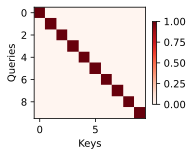

In [ ]:
attention_weights = torch.eye(10).reshape((1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')

### 11.1.2. Summary

The attention mechanism allows us to aggregate data from many (key, value) pairs. So far our discussion was quite abstract, simply describing a way to pool data. We have not explained yet where those mysterious queries, keys, and values might arise from. Some intuition might help here: for instance, in a regression setting, the query might correspond to the location where the regression should be carried out. The keys are the locations where past data was observed and the values are the (regression) values themselves. This is the so-called Nadaraya--Watson estimator (Nadaraya, 1964, Watson, 1964) that we will be studying in the next section.

By design, the attention mechanism provides a *differentiable* means of control by which a neural network can select elements from a set and to construct an associated weighted sum over representations.

### 11.1.3. Exercises

1. Suppose that you wanted to reimplement approximate (key, query) matches as used in classical databases, which attention function would you pick?

1. Suppose that the attention function is given by $a(\mathbf{q}, \mathbf{k}_i) = \mathbf{q}^\top \mathbf{k}_i$ and that $\mathbf{k}_i = \mathbf{v}_i$ for $i = 1, \ldots, m$. Denote by $p(\mathbf{k}_i; \mathbf{q})$ the probability distribution over keys when using the softmax normalization in (11.1.3). Prove that $\nabla_{\mathbf{q}} \mathop{\textrm{Attention}}(\mathbf{q}, \mathcal{D}) = \textrm{Cov}_{p(\mathbf{k}_i; \mathbf{q})}[\mathbf{k}_i]$.

1. Design a differentiable search engine using the attention mechanism.

1. Review the design of the Squeeze and Excitation Networks (Hu et al., 2018) and interpret them through the lens of the attention mechanism.

## 11.2. Attention Pooling by Similarity

Now that we have introduced the primary components of the attention mechanism, let's use them in a rather classical setting, namely regression and classification via *kernel density estimation* (Nadaraya, 1964, Watson, 1964). This detour simply provides additional background: it is entirely optional and can be skipped if needed. At their core, Nadaraya--Watson estimators rely on some similarity kernel $\alpha(\mathbf{q}, \mathbf{k})$ relating queries $\mathbf{q}$ to keys $\mathbf{k}$. Some common kernels are

$$\begin{aligned} \alpha(\mathbf{q}, \mathbf{k}) & = \exp\left(-\frac{1}{2} \|\mathbf{q} - \mathbf{k}\|^2 \right) && \textrm{Gaussian;} \\ \alpha(\mathbf{q}, \mathbf{k}) & = 1 \textrm{ if } \|\mathbf{q} - \mathbf{k}\| \leq 1 && \textrm{Boxcar;} \\ \alpha(\mathbf{q}, \mathbf{k}) & = \mathop{\mathrm{max}}\left(0, 1 - \|\mathbf{q} - \mathbf{k}\|\right) && \textrm{Epanechikov.} \end{aligned} \tag{11.2.1}$$

There are many more choices that we could pick. See a [Wikipedia article](https://en.wikipedia.org/wiki/Kernel_(statistics)) for a more extensive review and how the choice of kernels is related to kernel density estimation, sometimes also called *Parzen Windows* (Parzen, 1957). All of the kernels are heuristic and can be tuned. For instance, we can adjust the width, not only on a global basis but even on a per-coordinate basis. Regardless, all of them lead to the following equation for regression and classification alike:

$$f(\mathbf{q}) = \sum_i \mathbf{v}_i \frac{\alpha(\mathbf{q}, \mathbf{k}_i)}{\sum_j \alpha(\mathbf{q}, \mathbf{k}_j)}. \tag{11.2.2}$$

In the case of a (scalar) regression with observations $(\mathbf{x}_i, y_i)$ for features and labels respectively, $\mathbf{v}_i = y_i$ are scalars, $\mathbf{k}_i = \mathbf{x}_i$ are vectors, and the query $\mathbf{q}$ denotes the new location where $f$ should be evaluated. In the case of (multiclass) classification, we use one-hot-encoding of $y_i$ to obtain $\mathbf{v}_i$. One of the convenient properties of this estimator is that it requires no training. Even more so, if we suitably narrow the kernel with increasing amounts of data, the approach is consistent (Mack and Silverman, 1982), i.e., it will converge to some statistically optimal solution. Let's start by inspecting some kernels.

In [ ]:
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

d2l.use_svg_display()

### 11.2.1. Kernels and Data

All the kernels $\alpha(\mathbf{k}, \mathbf{q})$ defined in this section are *translation and rotation invariant*; that is, if we shift and rotate $\mathbf{k}$ and $\mathbf{q}$ in the same manner, the value of $\alpha$ remains unchanged. For simplicity we thus pick scalar arguments $k, q \in \mathbb{R}$ and pick the key $k = 0$ as the origin. This yields:

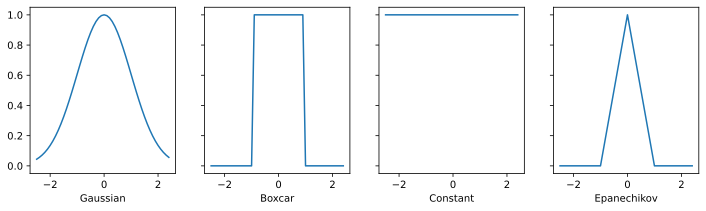

In [ ]:
# Define some kernels
def gaussian(x):
    return torch.exp(-x**2 / 2)

def boxcar(x):
    return torch.abs(x) < 1.0

def constant(x):
    return 1.0 + 0 * x

def epanechikov(x):
    return torch.max(1 - torch.abs(x), torch.zeros_like(x))

fig, axes = d2l.plt.subplots(1, 4, sharey=True, figsize=(12, 3))

kernels = (gaussian, boxcar, constant, epanechikov)
names = ('Gaussian', 'Boxcar', 'Constant', 'Epanechikov')
x = torch.arange(-2.5, 2.5, 0.1)
for kernel, name, ax in zip(kernels, names, axes):
    ax.plot(x.detach().numpy(), kernel(x).detach().numpy())
    ax.set_xlabel(name)

d2l.plt.show()

Different kernels correspond to different notions of range and smoothness. For instance, the boxcar kernel only attends to observations within a distance of $1$ (or some otherwise defined hyperparameter) and does so indiscriminately.

To see Nadaraya--Watson estimation in action, let's define some training data. In the following we use the dependency

$$y_i = 2\sin(x_i) + x_i + \epsilon, \tag{11.2.3}$$

where $\epsilon$ is drawn from a normal distribution with zero mean and unit variance. We draw 40 training examples.

In [ ]:
def f(x):
    return 2 * torch.sin(x) + x

n = 40
x_train, _ = torch.sort(torch.rand(n) * 5)
y_train = f(x_train) + torch.randn(n)
x_val = torch.arange(0, 5, 0.1)
y_val = f(x_val)

In [ ]:
print(f"x_train.shape: {x_train.shape}")
print(f"x_val.shape: {x_val.shape}")

x_train.shape: torch.Size([40])
x_val.shape: torch.Size([50])


---
牧之：为什么验证数据的标签不添加噪声？

通义：验证数据集的主要目的是评估模型在未见数据上的性能，以便调整模型参数、选择最佳模型版本或检测过拟合。为了确保验证结果的准确性和可靠性，验证数据及其标签通常需要保持干净、无噪声，原因包括：

- **评估准确性**：添加噪声到验证集的标签上会引入不必要的变异性，使得模型性能的评估变得不准确。这可能导致错误的结论，比如高估或低估模型的真实泛化能力。

- **避免误导优化**：模型训练过程中会参考验证集的性能表现来决定是否提前终止（early stopping）、调整学习率等。如果验证标签带有噪声，可能会误导这些决策过程，导致选择了一个实际上并不理想的模型版本。

- **保持一致性**：在机器学习研究和实践社区中，保持验证集的纯净是评价不同模型性能的基础。如果每个研究者或实践者都对验证集标签采取不同的噪声策略，那么比较不同模型或技术的效果将变得没有意义。

- **监测过拟合**：一个重要的用途是监测训练过程中是否发生过拟合。若验证集标签本身就不精确，那么观察到的表现下降可能无法准确归因于过拟合还是数据问题。

- **确保可复现性**：科学研究强调实验的可重复性和可复现性。如果验证数据的标签含有随机噪声，其他人尝试复现实验时很难得到一致的结果。

总之，验证数据及标签应该尽可能地代表模型未来可能遇到的真实情况，同时保证高度的准确性和一致性，这样才能有效地辅助模型的选择与优化。

### 11.2.2. Attention Pooling via Nadaraya–Watson Regression

Now that we have data and kernels, all we need is a function that computes the kernel regression estimates. Note that we also want to obtain the relative kernel weights in order to perform some minor diagnostics. Hence we first compute the kernel between all training features (covariates) `x_train` and all validation features `x_val`. This yields a matrix, which we subsequently normalize. When multiplied with the training labels `y_train` we obtain the estimates.

Recall attention pooling in (11.1.1). Let each validation feature be a query, and each training feature--label pair be a key--value pair. As a result, the  normalized relative kernel weights (`attention_w` below) are the *attention weights*.

In [ ]:
def nadaraya_watson(x_train, y_train, x_val, kernel):
    dists = x_train.reshape((-1, 1)) - x_val.reshape((1, -1))
    # Each column/row corresponds to each query/key
    k = kernel(dists).type(torch.float32)
    # Normalization over keys for each query
    attention_w = k / k.sum(0)
    y_hat = y_train@attention_w
    return y_hat, attention_w

---
牧之：这里用的是 similarity kernel。首先，通过 similarity kernel 计算待查询观察与key 之间的相似性。接着，将相似性在 key 维度归一化，得到归一化的相似性相似性。最后，查出 key 对应的 value，并通过归一化的相似性计算线性组合，得到最终结果。抽象来看，similarity kernel 的作用就是提供了 Attention Pooling。

Let’s have a look at the kind of estimates that the different kernels produce.

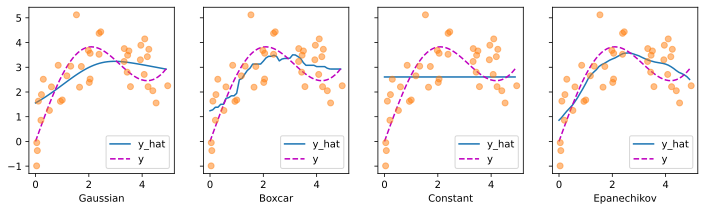

In [ ]:
def plot(x_train, y_train, x_val, y_val, kernels, names, attention=False):
    fig, axes = d2l.plt.subplots(1, 4, sharey=True, figsize=(12, 3))
    for kernel, name, ax in zip(kernels, names, axes):
        y_hat, attention_w = nadaraya_watson(x_train, y_train, x_val, kernel)
        if attention:
            pcm = ax.imshow(attention_w.detach().numpy(), cmap='Reds')
        else:
            ax.plot(x_val, y_hat)
            ax.plot(x_val, y_val, 'm--')
            ax.plot(x_train, y_train, 'o', alpha=0.5);
        ax.set_xlabel(name)
        if not attention:
            ax.legend(['y_hat', 'y'])
    if attention:
        fig.colorbar(pcm, ax=axes, shrink=0.7)

plot(x_train, y_train, x_val, y_val, kernels, names)

The first thing that stands out is that all three nontrivial kernels (Gaussian, Boxcar, and Epanechikov) produce fairly workable estimates that are not too far from the true function. Only the constant kernel that leads to the trivial estimate $f(x) = \frac{1}{n} \sum_i y_i$ produces a rather unrealistic result. Let's inspect the attention weighting a bit more closely:

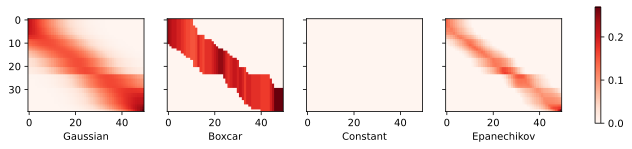

In [ ]:
plot(x_train, y_train, x_val, y_val, kernels, names, attention=True)

The visualization clearly shows why the estimates for Gaussian, Boxcar, and Epanechikov are very similar: after all, they are derived from very similar attention weights, despite the different functional form of the kernel. This raises the question as to whether this is always the case.

### 11.2.3. Adapting Attention Pooling

We could replace the Gaussian kernel with one of a different width. That is, we could use $\alpha(\mathbf{q}, \mathbf{k}) = \exp\left(-\frac{1}{2 \sigma^2} \|\mathbf{q} - \mathbf{k}\|^2 \right)$ where $\sigma^2$ determines the width of the kernel. Let's see whether this affects the outcomes.

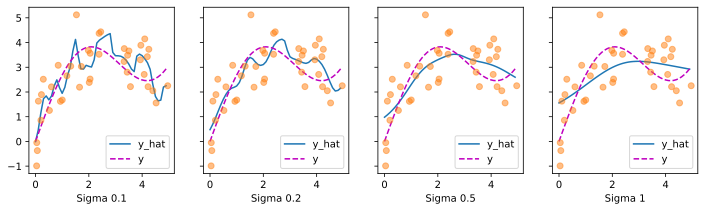

In [ ]:
sigmas = (0.1, 0.2, 0.5, 1)
names = ['Sigma ' + str(sigma) for sigma in sigmas]

def gaussian_with_width(sigma):
    return (lambda x: torch.exp(-x**2 / (2*sigma**2)))

kernels = [gaussian_with_width(sigma) for sigma in sigmas]
plot(x_train, y_train, x_val, y_val, kernels, names)

Clearly, the narrower the kernel, the less smooth the estimate. At the same time, it adapts better to the local variations. Let's look at the corresponding attention weights.

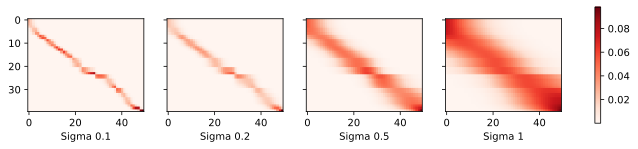

In [ ]:
plot(x_train, y_train, x_val, y_val, kernels, names, attention=True)

As we would expect, the narrower the kernel, the narrower the range of large attention weights. It is also clear that picking the same width might not be ideal. In fact, Silverman (1986) proposed a heuristic that depends on the local density. Many more such "tricks" have been proposed. For instance, Norelli et al. (2022) used a similar nearest-neighbor interpolation technique for designing cross-modal image and text representations.

The astute reader might wonder why we are providing this deep dive for a method that is over half a century old. First, it is one of the earliest precursors of modern attention mechanisms. Second, it is great for visualization. Third, and just as importantly, it demonstrates the limits of hand-crafted attention mechanisms. A much better strategy is to *learn* the mechanism, by learning the representations for queries and keys. This is what we will embark on in the following sections.

### 11.2.4. Summary

Nadaraya--Watson kernel regression is an early precursor of the current attention mechanisms. It can be used directly with little to no training or tuning, either for classification or regression. The attention weight is assigned according to the similarity (or distance) between query and key, and according to how many similar observations are available.

### 11.2.5. Exercises

1. Parzen windows density estimates are given by $\hat{p}(\mathbf{x}) = \frac{1}{n} \sum_i k(\mathbf{x}, \mathbf{x}_i)$. Prove that for binary classification the function $\hat{p}(\mathbf{x}, y=1) - \hat{p}(\mathbf{x}, y=-1)$, as obtained by Parzen windows is equivalent to Nadaraya--Watson classification.

1. Implement stochastic gradient descent to learn a good value for kernel widths in Nadaraya--Watson regression.
  - What happens if you just use the above estimates to minimize $(f(\mathbf{x_i}) - y_i)^2$ directly? Hint: $y_i$ is part of the terms used to compute $f$.
  - Remove $(\mathbf{x}_i, y_i)$ from the estimate for $f(\mathbf{x}_i)$ and optimize over the kernel widths. Do you still observe overfitting?

1. Assume that all $\mathbf{x}$ lie on the unit sphere, i.e., all satisfy $\|\mathbf{x}\| = 1$. Can you simplify the $\|\mathbf{x} - \mathbf{x}_i\|^2$ term in the exponential? Hint: we will later see that this is very closely related to dot product attention.

1. Recall that Mack and Silverman (1982) proved that Nadaraya--Watson estimation is consistent. How quickly should you reduce the scale for the attention mechanism as you get more data? Provide some intuition for your answer. Does it depend on the dimensionality of the data? How?

## 11.3. Attention Scoring Functions

In Section 11.2, we used a number of different distance-based kernels, including a Gaussian kernel to model interactions between queries and keys. As it turns out, distance functions are slightly more expensive to compute than dot products. As such, with the softmax operation to ensure nonnegative attention weights, much of the work has gone into **attention scoring functions** $a$ in (11.1.3) and Fig. 11.3.1 that are simpler to compute.

![](https://d2l.ai/_images/attention-output.svg)
<center>Fig. 11.3.1 Computing the output of attention pooling as a weighted average of values, where weights are computed with the attention scoring function $\mathit{a}$ and the softmax operation.</center>

---
牧之：这里也可以理解为什么要先去介绍这么远古的核方法了，因为核函数本来就是用来取代内积的。核方法可以被装进注意力机制。

In [ ]:
import math
import torch
from torch import nn
from d2l import torch as d2l

### 11.3.1. Dot Product Attention

Let's review the attention function (without exponentiation) from the Gaussian kernel for a moment:

$$a(\mathbf{q}, \mathbf{k}_i) = -\frac{1}{2} \|\mathbf{q} - \mathbf{k}_i\|^2  = \mathbf{q}^\top \mathbf{k}_i -\frac{1}{2} \|\mathbf{k}_i\|^2  -\frac{1}{2} \|\mathbf{q}\|^2. \tag{11.3.1}$$

First, note that the final term depends on $\mathbf{q}$ only. As such it is identical for all $(\mathbf{q}, \mathbf{k}_i)$ pairs. Normalizing the attention weights to $1$, as is done in (11.1.3), ensures that this term disappears entirely. Second, note that both batch and layer normalization (to be discussed later) lead to activations that have well-bounded, and often constant, norms $\|\mathbf{k}_i\|$. This is the case, for instance, whenever the keys $\mathbf{k}_i$ were generated by a layer norm. As such, we can drop it from the definition of $a$ without any major change in the outcome.

Last, we need to keep the order of magnitude of the arguments in the exponential function under control. Assume that all the elements of the query $\mathbf{q} \in \mathbb{R}^d$ and the key $\mathbf{k}_i \in \mathbb{R}^d$ are *independent and identically* drawn random variables with *zero mean* and *unit variance*. The dot product between both vectors has zero mean and a variance of $d$. To ensure that the variance of the dot product still remains $1$ regardless of vector length, we use the **scaled dot product attention** scoring function. That is, we rescale the dot product by $1/\sqrt{d}$. We thus arrive at the first commonly used attention function that is used, e.g., in Transformers (Vaswani et al., 2017):

$$a(\mathbf{q}, \mathbf{k}_i) = \mathbf{q}^\top \mathbf{k}_i / \sqrt{d}.\tag{11.3.2}$$

Note that attention weights $\alpha$ still need normalizing. We can simplify this further via (11.1.3) by using the softmax operation:

$$\alpha(\mathbf{q}, \mathbf{k}_i) = \mathrm{softmax}(a(\mathbf{q}, \mathbf{k}_i)) = \frac{\exp(\mathbf{q}^\top \mathbf{k}_i / \sqrt{d})}{\sum_{j=1} \exp(\mathbf{q}^\top \mathbf{k}_j / \sqrt{d})}. \tag{11.3.3}$$

As it turns out, all popular attention mechanisms use the softmax, hence we will limit ourselves to that in the remainder of this chapter.

### 11.3.2. Convenience Functions

We need a few functions to make the attention mechanism efficient to deploy. This includes tools for dealing with strings of variable lengths (common for natural language processing) and tools for efficient evaluation on minibatches (batch matrix multiplication).

#### 11.3.2.1. Masked Softmax Operation

Since we do not want blanks in our attention model we simply need to limit $\sum_{i=1}^n \alpha(\mathbf{q}, \mathbf{k}_i) \mathbf{v}_i$ to $\sum_{i=1}^l \alpha(\mathbf{q}, \mathbf{k}_i) \mathbf{v}_i$ for however long, $l \leq n$, the actual sentence is. Since it is such a common problem, it has a name: the **masked softmax operation**.

Let's implement it. Actually, the implementation cheats ever so slightly by setting the values of $\mathbf{v}_i$, for $i > l$, to zero. Moreover, it sets the attention weights to a large negative number, such as $-10^{6}$, in order to make their contribution to gradients and values vanish in practice. This is done since linear algebra kernels and operators are heavily optimized for GPUs and it is faster to be slightly wasteful in computation rather than to have code with conditional (if then else) statements.

In [ ]:
def masked_softmax(X, valid_lens):  #@ save
    """Perform softmax operation by masking elements on the last axis."""
    # X: 3D tensor, valid_lens: 1D or 2D tensor
    def _sequence_mask(X, valid_len, value=0):
        maxlen = X.size(1)
        mask = torch.arange((maxlen), dtype=torch.float32,
                            device=X.device)[None, :] < valid_len[:, None]
        X[~mask] = value
        return X

    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        # On the last axis, replace masked elements with a very large negative
        # value, whose exponentiation outputs 0
        X = _sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)

---
牧之：在 Seq2Seq RNN 模型中，输入的形状为 `(batch_size, num_steps)`，嵌入层会把它转换成 `(num_steps, batch_size, num_inputs)` 形状后，再输入到循环层。作为对比，注意力模型中，输入的形状为 `(batch_size, no. of queries, d)`。

In [ ]:
# Experiment
batch_size_ = 2
num_queries_ = 4
d_ = 6
X_ = torch.ones(batch_size_, num_queries_, d_)
shape_ = X_.shape
print(f"X_: {X_.shape}")
print(X_)

# ONE_DIM_FLAG = False
ONE_DIM_FLAG = True

if ONE_DIM_FLAG:
    # Case1: valid_lens_ is 1D
    valid_lens_ = torch.tensor([2, 3])
    print(f"valid_lens_: {valid_lens_.shape}")
    print(valid_lens_)
    valid_lens_ = torch.repeat_interleave(valid_lens_, num_queries_)
    print(f"valid_lens_: {valid_lens_.shape}")
    print(valid_lens_)
else:
    # Case2: valid_lens_ is 2D
    valid_lens_ = torch.tensor([[2, 1, 2, 3], [1, 2, 3, 4]])
    print(f"valid_lens_: {valid_lens_.shape}")
    print(valid_lens_)
    valid_lens_ = valid_lens_.reshape(-1)
    print(f"valid_lens_: {valid_lens_.shape}")
    print(valid_lens_)

X_ = X_.reshape(-1, d_)
print(f"X_: {X_.shape}")
print(X_)

maxlen_ = d_
print(torch.arange(maxlen_, dtype=torch.float32)[None, :])
print(valid_lens_[:, None])
mask_ = torch.arange(maxlen_, dtype=torch.float32)[None, :] < valid_lens_[:, None]
print(f"mask_: {mask_.shape}")
print(mask_)

value_ = 0
# value_ = -1e6
X_[~mask_] = value_
print(X_)
# print(X_.reshape(shape_))
# print(nn.functional.softmax(X_.reshape(shape_), dim=-1))

X_: torch.Size([2, 4, 6])
tensor([[[1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.]],

        [[1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.]]])
valid_lens_: torch.Size([2])
tensor([2, 3])
valid_lens_: torch.Size([8])
tensor([2, 2, 2, 2, 3, 3, 3, 3])
X_: torch.Size([8, 6])
tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])
tensor([[0., 1., 2., 3., 4., 5.]])
tensor([[2],
        [2],
        [2],
        [2],
        [3],
        [3],
        [3],
        [3]])
mask_: torch.Size([8, 6])
tensor([[ True,  True, False, False, False, False],
        [ True,  True, False, False, False, False],
        [ True,  T

---
牧之：注意力机制中，queries 的形状为 `(batch_size, no. of queries, d`)，这里的 d 到底是什么？是嵌入层的大小吗？从应用 softmax 操作来看，应该是嵌入层大小，但在什么情况下，需要把两个不同嵌入层大小的 queries 放到同一个网络呢？这里其实理解有误，masked softmax operation 并不是在嵌入层大小的维度进行掩蔽。观察 11.3.3 章节示例，queries 的形状为 `(batch_size, no. of queries, d`)，keys 的形状为 `(batch_size, no. of key-value pairs, d`)，两者的内积形状为 `(batch_size, no. of queries, no. of key-value pairs`)，masked softmax operation 是在 no. of key-value pairs 的维度上进行掩蔽。这样就又有一个问题，valid_lens 是从前往后进行掩蔽的，那如果选择不是从头开始的部分 k-v 对呢？参考一下 11.4.2 章节，不会有这个问题，因为是将 encoder 的 `enc_outputs` 作为 key 和 value 的。encoder 的输入是从前到后的序列，pad 必定是在最后。

To illustrate how this function works, consider a minibatch of two examples of size $2 \times 4$, where their valid lengths are $2$ and $3$, respectively. As a result of the masked softmax operation, values beyond the valid lengths for each pair of vectors are all masked as zero.

In [ ]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([2, 3]))

tensor([[[0.6440, 0.3560, 0.0000, 0.0000],
         [0.5363, 0.4637, 0.0000, 0.0000]],

        [[0.3664, 0.2797, 0.3538, 0.0000],
         [0.3703, 0.4162, 0.2135, 0.0000]]])

If we need more fine-grained control to specify the valid length for each of the two vectors of every example, we simply use a two-dimensional tensor of valid lengths. This yields:

In [ ]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([[1, 3], [2, 4]]))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.2318, 0.3686, 0.3996, 0.0000]],

        [[0.5984, 0.4016, 0.0000, 0.0000],
         [0.1520, 0.2771, 0.2964, 0.2745]]])

#### 11.3.2.2. Batch Matrix Multiplication

Another commonly used operation is to multiply batches of matrices by one another. This comes in handy when we have minibatches of queries, keys, and values. More specifically, assume that

$$\mathbf{Q} = [\mathbf{Q}_1, \mathbf{Q}_2, \ldots, \mathbf{Q}_n]  \in \mathbb{R}^{n \times a \times b}, \\
    \mathbf{K} = [\mathbf{K}_1, \mathbf{K}_2, \ldots, \mathbf{K}_n]  \in \mathbb{R}^{n \times b \times c}. \tag{11.3.4}$$

Then the batch matrix multiplication (BMM) computes the elementwise product

$$\textrm{BMM}(\mathbf{Q}, \mathbf{K}) = [\mathbf{Q}_1 \mathbf{K}_1, \mathbf{Q}_2 \mathbf{K}_2, \ldots, \mathbf{Q}_n \mathbf{K}_n] \in \mathbb{R}^{n \times a \times c}. \tag{11.3.5}$$

Let's see this in action in a deep learning framework.

---
牧之：这里的 n 是 batch_size，a 是 no. of queries，b 是 embedded_size（很多场合用 d 表示），c 是 no. of key-value pairs（很多场合用 m 表示）。可以在 `DotProductAttention` 代码演示中的 `keys.transpose(1, 2)` 语句得到验证。

In [ ]:
Q = torch.ones((2, 3, 4))
K = torch.ones((2, 4, 6))
d2l.check_shape(torch.bmm(Q, K), (2, 3, 6))

### 11.3.3. Scaled Dot Product Attention

Let's return to the dot product attention introduced in (11.3.2). In general, it requires that both the query and the key have the same vector length, say $d$, even though this can be addressed easily by replacing $\mathbf{q}^\top \mathbf{k}$ with $\mathbf{q}^\top \mathbf{M} \mathbf{k}$ where $\mathbf{M}$ is a matrix suitably chosen for translating between both spaces. For now assume that the dimensions match.

In practice, we often think of minibatches for efficiency, such as computing attention for $n$ queries and $m$ key-value pairs, where queries and keys are of length $d$ and values are of length $v$. The scaled dot product attention of queries $\mathbf Q\in\mathbb R^{n\times d}$, keys $\mathbf K\in\mathbb R^{m\times d}$, and values $\mathbf V\in\mathbb R^{m\times v}$ thus can be written as

$$ \mathrm{softmax}\left(\frac{\mathbf Q \mathbf K^\top }{\sqrt{d}}\right) \mathbf V \in \mathbb{R}^{n\times v}. \tag{11.3.6}$$

Note that when applying this to a minibatch, we need the batch matrix multiplication introduced in (11.3.5). In the following implementation of the scaled dot product attention, we use dropout for model regularization.

---
牧之：这的符号选的不好。这里的 n 是 no. of queries，容易与 batch_size 搞混。下面 `scores` 的形状是三维的，`(batch_size, no. of queries, no. of key-value pairs)`。

In [ ]:
class DotProductAttention(nn.Module):  #@ save
    """Scaled dot product attention."""
    def __init__(self, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    # Shape of queries: (batch_size, no. of queries, d)
    # Shape of keys: (batch_size, no. of key-value pairs, d)
    # Shape of values: (batch_size, no. of key-value pairs, value dimension)
    # Shape of valid_lens: (batch_size,) or (batch_size, no. of queries)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # Swap the last two dimensions of keys with keys.transpose(1, 2)
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

---
牧之：这里可能有点问题，因为在推理模式下也会执行 dropout 了。

To illustrate how the `DotProductAttention` class works, we use the same keys, values, and valid lengths from the earlier toy example for additive attention. For the purpose of our example we assume that we have a minibatch size of $2$, a total of $10$ keys and values, and that the dimensionality of the values is $4$. Lastly, we assume that the valid length per observation is $2$ and $6$ respectively. Given that, we expect the output to be a $2 \times 1 \times 4$ tensor, i.e., one row per example of the minibatch.

In [ ]:
queries = torch.normal(0, 1, (2, 1, 2))
keys = torch.normal(0, 1, (2, 10, 2))
values = torch.normal(0, 1, (2, 10, 4))
valid_lens = torch.tensor([2, 6])

attention = DotProductAttention(dropout=0.5)
attention.eval()
d2l.check_shape(attention(queries, keys, values, valid_lens), (2, 1, 4))

Let's check whether the attention weights actually vanish for anything beyond the second and sixth column respectively (because of setting the valid length to $2$ and $6$).

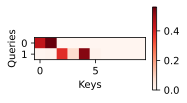

In [ ]:
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')

### 11.3.4. Additive Attention

When queries $\mathbf{q}$ and keys $\mathbf{k}$ are vectors of different dimension, we can either use a matrix to address the mismatch via $\mathbf{q}^\top \mathbf{M} \mathbf{k}$, or we can use additive attention as the scoring function. Another benefit is that, as its name indicates, the attention is additive. This can lead to some minor computational savings. Given a query $\mathbf{q} \in \mathbb{R}^q$ and a key $\mathbf{k} \in \mathbb{R}^k$, the **additive attention** scoring function (Bahdanau et al., 2014) is given by

$$a(\mathbf q, \mathbf k) = \mathbf w_v^\top \textrm{tanh}(\mathbf W_q\mathbf q + \mathbf W_k \mathbf k) \in \mathbb{R}, \tag{11.3.7}$$

where $\mathbf W_q\in\mathbb R^{h\times q}$, $\mathbf W_k\in\mathbb R^{h\times k}$, and $\mathbf w_v\in\mathbb R^{h}$ are the learnable parameters. This term is then fed into a softmax to ensure both nonnegativity and normalization. An equivalent interpretation of (11.3.7) is that the query and key are concatenated and fed into an MLP with a single hidden layer. Using $\tanh$ as the activation function and disabling bias terms, we implement additive attention as follows:

---
牧之：之前的注意力机制是不需要学习的，加性注意力使用了一个（简单的）神经网络来模拟注意力评分函数。$\mathbf q$ 和 $\mathbf k$ 的长度可以不同，两者分别通过一个 `num_hiddens` 的隐藏层来屏蔽长度差异，再将两者的隐藏层输出（升维后）相加后通过激活函数激活，再用一个全连接层（不带激活函数）输出。这种神经网络表达比固定的内积计算更有表达能力。

In [ ]:
class AdditiveAttention(nn.Module):  #@ save
    """Additive attention."""
    def __init__(self, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = nn.LazyLinear(num_hiddens, bias=False)
        self.W_q = nn.LazyLinear(num_hiddens, bias=False)
        self.w_v = nn.LazyLinear(1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        # After dimension expansion, shape of queries: (batch_size, no. of
        # queries, 1, num_hiddens) and shape of keys: (batch_size, 1, no. of
        # key-value pairs, num_hiddens). Sum them up with broadcasting
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        # There is only one output of self.w_v, so we remove the last
        # one-dimensional entry from the shape. Shape of scores: (batch_size,
        # no. of queries, no. of key-value pairs)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        # Shape of values: (batch_size, no. of key-value pairs, value
        # dimension)
        return torch.bmm(self.dropout(self.attention_weights), values)

Let's see how `AdditiveAttention` works. In our toy example we pick queries, keys and values of size $(2, 1, 20)$, $(2, 10, 2)$ and $(2, 10, 4)$, respectively. This is identical to our choice for `DotProductAttention`, except that now the queries are $20$-dimensional. Likewise, we pick $(2, 6)$ as the valid lengths for the sequences in the minibatch.

In [ ]:
queries = torch.normal(0, 1, (2, 1, 20))

attention = AdditiveAttention(num_hiddens=8, dropout=0.1)
attention.eval()
d2l.check_shape(attention(queries, keys, values, valid_lens), (2, 1, 4))

/home/lancer/miniforge3/envs/d2l/lib/python3.9/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


When reviewing the attention function we see a behavior that is qualitatively quite similar to that of `DotProductAttention`. That is, only terms within the chosen valid length $(2, 6)$ are nonzero.

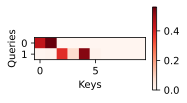

In [ ]:
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')

### 11.3.5. Summary

In this section we introduced the two key attention scoring functions: dot product and additive attention. They are effective tools for aggregating across sequences of variable length. In particular, the dot product attention is the mainstay of modern Transformer architectures. When queries and keys are vectors of different lengths, we can use the additive attention scoring function instead. Optimizing these layers is one of the key areas of advance in recent years. For instance, [NVIDIA's Transformer Library](https://docs.nvidia.com/deeplearning/transformer-engine/user-guide/index.html) and Megatron (Shoeybi et al., 2019) crucially rely on efficient variants of the attention mechanism. We will dive into this in quite a bit more detail as we review Transformers in later sections.

### 11.3.6. Exercises

1. Implement distance-based attention by modifying the `DotProductAttention` code. Note that you only need the squared norms of the keys $\|\mathbf{k}_i\|^2$ for an efficient implementation.

1. Modify the dot product attention to allow for queries and keys of different dimensionalities by employing a matrix to adjust dimensions.

1. How does the computational cost scale with the dimensionality of the keys, queries, values, and their number? What about the memory bandwidth requirements?

## 11.4. The Bahdanau Attention Mechanism

When we encountered machine translation in Section 10.7, we designed an encoder--decoder architecture for sequence-to-sequence learning based on two RNNs (Sutskever et al., 2014). Specifically, the RNN encoder transforms a variable-length sequence into a *fixed-shape* context variable. Then, the RNN decoder generates the output (target) sequence token by token based on the generated tokens and the context variable.

Recall Fig. 10.7.2 which we repeat (Fig. 11.4.1) with some additional detail. Conventionally, in an RNN all relevant information about a source sequence is translated into some internal *fixed-dimensional* state representation by the encoder. It is this very state that is used by the decoder as the complete and exclusive source of information for generating the translated sequence. In other words, the sequence-to-sequence mechanism treats the intermediate state as a sufficient statistic of whatever string might have served as input.

![](https://d2l.ai/_images/seq2seq-state.svg)
<center>Fig. 11.4.1 Sequence-to-sequence model. The state, as generated by the encoder, is the only piece of information shared between the encoder and the decoder.</center>

---
牧之：这里的 state 在某种程度上确实可以看做是一个动态的数据库。这样就可以把注意力机制用进去了。

While this is quite reasonable for short sequences, it is clear that it is infeasible for long ones, such as a book chapter or even just a very long sentence. After all, before too long there will simply not be enough "space" in the intermediate representation to store all that is important in the source sequence. Consequently the decoder will fail to translate long and complex sentences. One of the first to encounter this was Graves (2013) who tried to design an RNN to generate handwritten text. Since the source text has arbitrary length they designed a differentiable attention model to align text characters with the much longer pen trace, where the alignment moves only in one direction. This, in turn, draws on decoding algorithms in speech recognition, e.g., hidden Markov models (Rabiner and Juang, 1993).

Inspired by the idea of learning to align, Bahdanau et al. (2014) proposed a differentiable attention model *without* the unidirectional alignment limitation. When predicting a token, if not all the input tokens are relevant, the model aligns (or attends) only to parts of the input sequence that are deemed relevant to the current prediction. This is then used to update the current state before generating the next token. While quite innocuous in its description, this **Bahdanau attention mechanism** has arguably turned into one of the most influential ideas of the past decade in deep learning, giving rise to Transformers (Vaswani et al., 2017) and many related new architectures.

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

### 11.4.1. Model

We follow the notation introduced by the sequence-to-sequence architecture of Section 10.7, in particular (10.7.3). The key idea is that instead of keeping the state, i.e., the context variable $\mathbf{c}$ summarizing the source sentence, as fixed, we dynamically update it, as a function of both the original text (encoder hidden states $\mathbf{h}_{t}$) and the text that was already generated (decoder hidden states $\mathbf{s}_{t'-1}$). This yields $\mathbf{c}_{t'}$, which is updated after any decoding time step $t'$. Suppose that the input sequence is of length $T$. In this case the context variable is the output of attention pooling:

$$\mathbf{c}_{t'} = \sum_{t=1}^{T} \alpha(\mathbf{s}_{t' - 1}, \mathbf{h}_{t}) \mathbf{h}_{t}. \tag{11.4.1}$$

We used $\mathbf{s}_{t' - 1}$ as the query, and $\mathbf{h}_{t}$ as both the key and the value. Note that $\mathbf{c}_{t'}$ is then used to generate the state $\mathbf{s}_{t'}$ and to generate a new token: see (10.7.3). In particular, the attention weight $\alpha$ is computed as in (11.3.3) using the additive attention scoring function defined by (11.3.7). This RNN encoder--decoder architecture using attention is depicted in Fig. 11.4.2. Note that later this model was modified so as to include the already generated tokens in the decoder as further context (i.e., the attention sum does not stop at $T$ but rather it proceeds up to $t'-1$). For instance, see Chan et al. (2015) for a description of this strategy, as applied to speech recognition.

![](https://d2l.ai/_images/seq2seq-details-attention.svg)
<center>Fig. 11.4.2 Layers in an RNN encoder--decoder model with the Bahdanau attention mechanism.</center>

### 11.4.2. Defining the Decoder with Attention

To implement the RNN encoder--decoder with attention, we only need to redefine the decoder (omitting the generated symbols from the attention function simplifies the design). Let's begin with the base interface for decoders with attention by defining the quite unsurprisingly named `AttentionDecoder` class.

In [ ]:
class AttentionDecoder(d2l.Decoder):  #@ save
    """The base attention-based decoder interface."""
    def __init__(self):
        super().__init__()

    @property
    def attention_weights(self):
        raise NotImplementedError

We need to implement the RNN decoder in the `Seq2SeqAttentionDecoder` class. The state of the decoder is initialized with (i) the hidden states of the last layer of the encoder at all time steps, used as keys and values for attention; (ii) the hidden state of the encoder at all layers at the final time step, which serves to initialize the hidden state of the decoder; and (iii) the valid length of the encoder, to exclude the padding tokens in attention pooling. At each decoding time step, the hidden state of the final layer of the decoder, obtained at the previous time step, is used as the query of the attention mechanism. Both the output of the attention mechanism and the input embedding are concatenated to serve as the input of the RNN decoder.

In [ ]:
class Seq2SeqAttentionDecoder(AttentionDecoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0):
        super().__init__()
        self.attention = d2l.AdditiveAttention(num_hiddens, dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(
            embed_size + num_hiddens, num_hiddens, num_layers,
            dropout=dropout)
        self.dense = nn.LazyLinear(vocab_size)
        self.apply(d2l.init_seq2seq)

    def init_state(self, enc_outputs, enc_valid_lens):
        # Shape of outputs: (num_steps, batch_size, num_hiddens).
        # Shape of hidden_state: (num_layers, batch_size, num_hiddens)
        outputs, hidden_state = enc_outputs
        return (outputs.permute(1, 0, 2), hidden_state, enc_valid_lens)

    def forward(self, X, state):
        # Shape of enc_outputs: (batch_size, num_steps, num_hiddens).
        # Shape of hidden_state: (num_layers, batch_size, num_hiddens)
        enc_outputs, hidden_state, enc_valid_lens = state
        # Shape of the output X: (num_steps, batch_size, embed_size)
        X = self.embedding(X).permute(1, 0, 2)
        outputs, self._attention_weights = [], []
        for x in X:
            # Shape of query: (batch_size, 1, num_hiddens)
            query = torch.unsqueeze(hidden_state[-1], dim=1)
            # Shape of context: (batch_size, 1, num_hiddens)
            context = self.attention(
                query, enc_outputs, enc_outputs, enc_valid_lens)
            # Concatenate on the feature dimension
            x = torch.cat((context, torch.unsqueeze(x, dim=1)), dim=-1)
            # Reshape x as (1, batch_size, embed_size + num_hiddens)
            out, hidden_state = self.rnn(x.permute(1, 0, 2), hidden_state)
            outputs.append(out)
            self._attention_weights.append(self.attention.attention_weights)
        # After fully connected layer transformation, shape of outputs:
        # (num_steps, batch_size, vocab_size)
        outputs = self.dense(torch.cat(outputs, dim=0))
        return outputs.permute(1, 0, 2), [enc_outputs, hidden_state,
                                          enc_valid_lens]

    @property
    def attention_weights(self):
        return self._attention_weights

In the following, we test the implemented decoder with attention using a minibatch of four sequences, each of which are seven time steps long.

In [ ]:
vocab_size, embed_size, num_hiddens, num_layers = 10, 8, 16, 2
batch_size, num_steps = 4, 7
encoder = d2l.Seq2SeqEncoder(vocab_size, embed_size, num_hiddens, num_layers)
decoder = Seq2SeqAttentionDecoder(vocab_size, embed_size, num_hiddens, num_layers)
X = torch.zeros((batch_size, num_steps), dtype=torch.long)
state = decoder.init_state(encoder(X), None)
output, state = decoder(X, state)
d2l.check_shape(output, (batch_size, num_steps, vocab_size))
d2l.check_shape(state[0], (batch_size, num_steps, num_hiddens))
d2l.check_shape(state[1][0], (batch_size, num_hiddens))

/home/lancer/miniforge3/envs/d2l/lib/python3.9/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


### 11.4.3. Training

Now that we specified the new decoder we can proceed analogously to Section 10.7.6: specify the hyperparameters, instantiate a regular encoder and a decoder with attention, and train this model for machine translation.

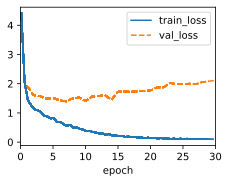

In [ ]:
data = d2l.MTFraEng(batch_size=128)
embed_size, num_hiddens, num_layers, dropout = 256, 256, 2, 0.2
encoder = d2l.Seq2SeqEncoder(
    len(data.src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqAttentionDecoder(
    len(data.tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
model = d2l.Seq2Seq(encoder, decoder, tgt_pad=data.tgt_vocab['<pad>'],
                    lr=0.005)
trainer = d2l.Trainer(max_epochs=30, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

After the model is trained, we use it to translate a few English sentences into French and compute their BLEU scores.

In [ ]:
engs = ['go .', 'i lost .', 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
preds, _ = model.predict_step(
    data.build(engs, fras), d2l.try_gpu(), data.num_steps)
for en, fr, p in zip(engs, fras, preds):
    translation = []
    for token in data.tgt_vocab.to_tokens(p):
        if token == '<eos>':
            break
        translation.append(token)
    print(f'{en} => {translation}, bleu,'
          f'{d2l.bleu(" ".join(translation), fr, k=2):.3f}')

go . => ['va', '!'], bleu,1.000
i lost . => ["j'ai", 'perdu', '.'], bleu,1.000
he's calm . => ['soyez', 'calme', '.'], bleu,0.492
i'm home . => ['je', 'suis', 'chez', 'moi', '.'], bleu,1.000


Let’s visualize the attention weights when translating the last English sentence. We see that each query assigns non-uniform weights over key–value pairs. It shows that at each decoding step, different parts of the input sequences are selectively aggregated in the attention pooling.

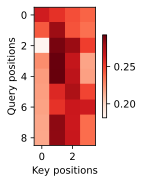

In [ ]:
_, dec_attention_weights = model.predict_step(
    data.build([engs[-1]], [fras[-1]]), d2l.try_gpu(), data.num_steps, True)
attention_weights = torch.cat(
    [step[0][0][0] for step in dec_attention_weights], 0)
attention_weights = attention_weights.reshape((1, 1, -1, data.num_steps))

# Plus one to include the end-of-sequence token
d2l.show_heatmaps(
    attention_weights[:, :, :, :len(engs[-1].split()) + 1].cpu(),
    xlabel='Key positions', ylabel='Query positions')

### 11.4.4. Summary

When predicting a token, if not all the input tokens are relevant, the RNN encoder--decoder with the Bahdanau attention mechanism selectively aggregates different parts of the input sequence. This is achieved by treating the state (context variable) as an output of additive attention pooling. In the RNN encoder--decoder, the Bahdanau attention mechanism treats the decoder hidden state at the previous time step as the query, and the encoder hidden states at all the time steps as both the keys and values.

### 11.4.5. Exercises

1. Replace GRU with LSTM in the experiment.

1. Modify the experiment to replace the additive attention scoring function with the scaled dot-product. How does it influence the training efficiency?

## 11.5. Multi-Head Attention

In practice, given the same set of queries, keys, and values we may want our model to combine knowledge from different behaviors of the same attention mechanism, such as capturing dependencies of various ranges (e.g., shorter-range vs. longer-range) within a sequence. Thus, it may be beneficial to allow our attention mechanism to jointly use different representation subspaces of queries, keys, and values.

To this end, instead of performing a single attention pooling, queries, keys, and values can be transformed with $h$ independently learned linear projections. Then these $h$ projected queries, keys, and values are fed into attention pooling in parallel. In the end, $h$ attention-pooling outputs are concatenated and transformed with another learned linear projection to produce the final output. This design is called **multi-head attention**, where each of the $h$ attention pooling outputs is a *head* (Vaswani et al., 2017). Using fully connected layers to perform learnable linear transformations, Fig. 11.5.1 describes multi-head attention.

![](https://d2l.ai/_images/multi-head-attention.svg)
<center>Fig. 11.5.1 Multi-head attention, where multiple heads are concatenated then linearly transformed.</center>

In [ ]:
import math
import torch
from torch import nn
from d2l import torch as d2l

### 11.5.1. Model

Before providing the implementation of multi-head attention, let's formalize this model mathematically. Given a query $\mathbf{q} \in \mathbb{R}^{d_q}$, a key $\mathbf{k} \in \mathbb{R}^{d_k}$, and a value $\mathbf{v} \in \mathbb{R}^{d_v}$, each attention head $\mathbf{h}_i$  ($i = 1, \ldots, h$) is computed as

$$\mathbf{h}_i = f(\mathbf W_i^{(q)}\mathbf q, \mathbf W_i^{(k)}\mathbf k,\mathbf W_i^{(v)}\mathbf v) \in \mathbb R^{p_v},$$

where $\mathbf W_i^{(q)}\in\mathbb R^{p_q\times d_q}$, $\mathbf W_i^{(k)}\in\mathbb R^{p_k\times d_k}$, and $\mathbf W_i^{(v)}\in\mathbb R^{p_v\times d_v}$ are learnable parameters and $f$ is attention pooling, such as additive attention and scaled dot product attention in Section 11.3. The multi-head attention output is another linear transformation via learnable parameters $\mathbf W_o\in\mathbb R^{p_o\times h p_v}$ of the concatenation of $h$ heads:

$$\mathbf W_o \begin{bmatrix}\mathbf h_1\\\vdots\\\mathbf h_h\end{bmatrix} \in \mathbb{R}^{p_o}.$$

Based on this design, each head may attend to different parts of the input. More sophisticated functions than the simple weighted average can be expressed.

### 11.5.2. Implementation

In our implementation, we choose the scaled dot product attention for each head of the multi-head attention. To avoid significant growth of computational cost and parametrization cost, we set $p_q = p_k = p_v = p_o / h$. Note that $h$ heads can be computed in parallel if we set the number of outputs of linear transformations for the query, key, and value to $p_q h = p_k h = p_v h = p_o$. In the following implementation, $p_o$ is specified via the argument `num_hiddens`.

In [ ]:
class MultiHeadAttention(d2l.Module):  #@ save
    """Multi-head attention."""
    def __init__(self, num_hiddens, num_heads, dropout, bias=False, **kwargs):
        super().__init__()
        self.num_heads = num_heads
        self.attention = d2l.DotProductAttention(dropout)
        self.W_q = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_k = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_v = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_o = nn.LazyLinear(num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        # Shape of queries, keys, or values:
        # (batch_size, no. of queries or key-value pairs, num_hiddens)
        # Shape of valid_lens: (batch_size,) or (batch_size, no. of queries)
        # After transposing, shape of output queries, keys, or values:
        # (batch_size * num_heads, no. of queries or key-value pairs,
        # num_hiddens / num_heads)
        queries = self.transpose_qkv(self.W_q(queries))
        keys = self.transpose_qkv(self.W_k(keys))
        values = self.transpose_qkv(self.W_v(values))

        if valid_lens is not None:
            # On axis 0, copy the first item (scalar or vector) for num_heads
            # times, then copy the next item, and so on
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)

        # Shape of output: (batch_size * num_heads, no. of queries,
        # num_hiddens / num_heads)
        output = self.attention(queries, keys, values, valid_lens)
        # Shape of output_concat: (batch_size, no. of queries, num_hiddens)
        output_concat = self.transpose_output(output)
        return self.W_o(output_concat)

---
牧之：
- 这里使用了并行计算的模式。首先，将 `queries`、`keys` 和 `values` 的编码维度 `num_hiddens` 都降低 `num_heads` 倍，转移到样本数量这个维度，样本数量增加了 `num_heads` 倍。这相当于用以一个更小的编码维度 `num_hiddens/num_heads` 并行计算了更多的输入样本 `batch_size*num_heads`。然后，再把 `batch_size*num_heads` 个输出结果拼接起来，分配到 `num_heads` 个 head 上去，形成最终的输出维度 `num_hiddens`。所以，这里复用的不是 attention 计算机制，它本来就是 `queries`、`keys` 和 `values` 共用的；这里真正复用的是 `queries`、`keys` 和 `values` 对 `num_heads` 个 head 的线性输出，理论上，对于 `num_heads` 个 head，它们可以使用不同的网络参数，但在并行计算机制里，这 `num_heads` 个 head 共享了相同的参数。
- 这里 `torch.repeat_interleave` 的作用和 `masked_softmax` 中的 `torch.repeat_interleave` 的作用不同。前者是为了先在 `num_heads` 层面补齐，后者是为了在 `no. of queries` 层面补齐。

To allow for parallel computation of multiple heads, the above `MultiHeadAttention` class uses two transposition methods as defined below. Specifically, the `transpose_output` method reverses the operation of the `transpose_qkv` method.

In [ ]:
@d2l.add_to_class(MultiHeadAttention)  #@ save
def transpose_qkv(self, X):
    """Transposition for parallel computation of multiple attention heads."""
    # Shape of input X: (batch_size, no. of queries or key-value pairs,
    # num_hiddens). Shape of output X: (batch_size, no. of queries or
    # key-value pairs, num_heads, num_hiddens / num_heads)
    X = X.reshape(X.shape[0], X.shape[1], self.num_heads, -1)
    # Shape of output X: (batch_size, num_heads, no. of queries or key-value
    # pairs, num_hiddens / num_heads)
    X = X.permute(0, 2, 1, 3)
    # Shape of output: (batch_size * num_heads, no. of queries or key-value
    # pairs, num_hiddens / num_heads)
    return X.reshape(-1, X.shape[2], X.shape[3])

@d2l.add_to_class(MultiHeadAttention)  #@ save
def transpose_output(self, X):
    """Reverse the operation of transpose_qkv."""
    X = X.reshape(-1, self.num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)

Let's test our implemented `MultiHeadAttention` class using a toy example where keys and values are the same. As a result, the shape of the multi-head attention output is (`batch_size`, `num_queries`, `num_hiddens`).

In [ ]:
num_hiddens, num_heads = 100, 5
attention = MultiHeadAttention(num_hiddens, num_heads, 0.5)
batch_size, num_queries, num_kvpairs = 2, 4, 6
valid_lens = torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
Y = torch.ones((batch_size, num_kvpairs, num_hiddens))
d2l.check_shape(attention(X, Y, Y, valid_lens),
                (batch_size, num_queries, num_hiddens))

### 11.5.3. Summary

Multi-head attention combines knowledge of the same attention pooling via different representation subspaces of queries, keys, and values. To compute multiple heads of multi-head attention in parallel, proper tensor manipulation is needed.

### 11.5.4. Exercises

1. Visualize attention weights of multiple heads in this experiment.

1. Suppose that we have a trained model based on multi-head attention and we want to prune less important attention heads to increase the prediction speed. How can we design experiments to measure the importance of an attention head?

## 11.6. Self-Attention and Positional Encoding

In deep learning, we often use CNNs or RNNs to encode sequences. Now with attention mechanisms in mind, imagine feeding a sequence of tokens into an attention mechanism such that at every step, each token has its own query, keys, and values. Here, when computing the value of a token's representation at the next layer, the token can attend (via its query vector) to any other's token (matching based on their key vectors). Using the full set of query-key compatibility scores, we can compute, for each token, a representation by building the appropriate weighted sum over the other tokens. Because every token is attending to each other token (unlike the case where decoder steps attend to encoder steps), such architectures are typically described as **self-attention** models (Lin et al., 2017, Vaswani et al., 2017), and elsewhere described as *intra-attention* model (Cheng et al., 2016, Parikh et al., 2016, Paulus et al., 2017). In this section, we will discuss sequence encoding using self-attention, including using additional information for the sequence order.

In [ ]:
import math
import torch
from torch import nn
from d2l import torch as d2l

### 11.6.1. Self-Attention

Given a sequence of input tokens $\mathbf{x}_1, \ldots, \mathbf{x}_n$ where any $\mathbf{x}_i \in \mathbb{R}^d$ ($1 \leq i \leq n$), its self-attention outputs a sequence of the same length $\mathbf{y}_1, \ldots, \mathbf{y}_n$, where

$$\mathbf{y}_i = f(\mathbf{x}_i, (\mathbf{x}_1, \mathbf{x}_1), \ldots, (\mathbf{x}_n, \mathbf{x}_n)) \in \mathbb{R}^d \tag{11.6.1}$$

according to the definition of attention pooling in (11.1.1). Using multi-head attention, the following code snippet computes the self-attention of a tensor with shape (batch size, number of time steps or sequence length in tokens, $d$). The output tensor has the same shape.

In [ ]:
num_hiddens, num_heads = 100, 5
attention = d2l.MultiHeadAttention(num_hiddens, num_heads, 0.5)
batch_size, num_queries, valid_lens = 2, 4, torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
d2l.check_shape(attention(X, X, X, valid_lens),
                (batch_size, num_queries, num_hiddens))

### 11.6.2. Comparing CNNs, RNNs, and Self-Attention

Let's compare architectures for mapping a sequence of $n$ tokens to another one of equal length, where each input or output token is represented by a $d$-dimensional vector. Specifically, we will consider CNNs, RNNs, and self-attention. We will compare their computational complexity, sequential operations, and maximum path lengths. Note that sequential operations prevent parallel computation, while a shorter path between any combination of sequence positions makes it easier to learn long-range dependencies within the sequence (Hochreiter et al., 2001).

![](https://d2l.ai/_images/cnn-rnn-self-attention.svg)
<center>Fig. 11.6.1 Comparing CNN (padding tokens are omitted), RNN, and self-attention architectures.</center>

Let's regard any text sequence as a "one-dimensional image". Similarly, one-dimensional CNNs can process local features such as $n$-grams in text. Given a sequence of length $n$, consider a convolutional layer whose kernel size is $k$, and whose numbers of input and output channels are both $d$. The computational complexity of the convolutional layer is $\mathcal{O}(knd^2)$. As Fig. 11.6.1 shows, CNNs are hierarchical, so there are $\mathcal{O}(1)$ sequential operations and the maximum path length is $\mathcal{O}(n/k)$. For example, $\mathbf{x}_1$ and $\mathbf{x}_5$ are within the receptive field of a two-layer CNN with kernel size 3 in Fig. 11.6.1.

When updating the hidden state of RNNs, multiplication of the $d \times d$ weight matrix and the $d$-dimensional hidden state has a computational complexity of $\mathcal{O}(d^2)$. Since the sequence length is $n$, the computational complexity of the recurrent layer is $\mathcal{O}(nd^2)$. According to Fig. 11.6.1, there are $\mathcal{O}(n)$ sequential operations that cannot be parallelized and the maximum path length is also $\mathcal{O}(n)$.

In self-attention, the queries, keys, and values are all $n \times d$ matrices. Consider the scaled dot product attention in (11.3.6), where an $n \times d$ matrix is multiplied by a $d \times n$ matrix, then the output $n \times n$ matrix is multiplied by an $n \times d$ matrix. As a result, the self-attention has a $\mathcal{O}(n^2d)$ computational complexity. As we can see from Fig. 11.6.1, each token is directly connected to any other token via self-attention. Therefore, computation can be parallel with $\mathcal{O}(1)$ sequential operations and the maximum path length is also $\mathcal{O}(1)$.

All in all, both CNNs and self-attention enjoy parallel computation and self-attention has the shortest maximum path length. However, the quadratic computational complexity with respect to the sequence length makes self-attention prohibitively slow for very long sequences.

### 11.6.3. Positional Encoding

Unlike RNNs, which recurrently process tokens of a sequence one-by-one, self-attention ditches sequential operations in favor of parallel computation. Note that self-attention by itself does not preserve the order of the sequence. What do we do if it really matters that the model knows in which order the input sequence arrived?

The dominant approach for preserving information about the order of tokens is to represent this to the model as an additional input associated with each token. These inputs are called **positional encodings**, and they can either be learned or fixed *a priori*. We now describe a simple scheme for fixed positional encodings based on sine and cosine functions (Vaswani et al., 2017).

Suppose that the input representation $\mathbf{X} \in \mathbb{R}^{n \times d}$ contains the $d$-dimensional embeddings for $n$ tokens of a sequence. The positional encoding outputs $\mathbf{X} + \mathbf{P}$ using a positional embedding matrix $\mathbf{P} \in \mathbb{R}^{n \times d}$ of the same shape, whose element on the $i^\textrm{th}$ row and the $(2j)^\textrm{th}$ or the $(2j + 1)^\textrm{th}$ column is

$$\begin{aligned} p_{i, 2j} &= \sin\left(\frac{i}{10000^{2j/d}}\right),\\p_{i, 2j+1} &= \cos\left(\frac{i}{10000^{2j/d}}\right).\end{aligned} \tag{11.6.2}$$

At first glance, this trigonometric function design looks weird. Before we give explanations of this design, let's first implement it in the following `PositionalEncoding` class.

---
牧之：公式 p 的下标分为两部分：
- i 是位置变量，是待输入的 token 的位置值，对应到以下代码 P 里的行索引。位置变量 i 与 max_len 有关，其范围在 0~min(act_len, max_len)-1 之间。
- 2j 和 2j+1 是什么？任一一个位置编码的编码长度索引，2j 是用 sin 函数编码，2j+1 是用 cos 函数编码。整个编码长度为是一个超参数 num_hiddens。j 越大，分母越大，频率越低，sin 和 cos 的变化频率越低。

In [ ]:
class PositionalEncoding(nn.Module):  #@ save
    """Positional encoding."""
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        # Create a long enough P
        self.P = torch.zeros((1, max_len, num_hiddens))
        X = torch.arange(max_len, dtype=torch.float32).reshape(
            -1, 1) / torch.pow(10000, torch.arange(
            0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :].to(X.device)
        return self.dropout(X)

---
牧之：在位置编码中，`max_len` 和 `num_hiddens` 分别充当了什么样的角色？

通义：在 `PositionalEncoding` 类中，`max_len` 和 `num_hiddens` 分别扮演着不同的角色：

1. **`max_len`**：这个参数表示序列的最大可能长度。位置编码 `P` 是一个三维张量 `(1, max_len, num_hiddens)`，其中第一维 1 代表 `batch size`，`max_len` 是为了覆盖所有可能的序列长度。当给定的输入序列长度小于 `max_len` 时，`P` 只会使用与输入序列相同长度的部分。`max_len` 通常设置为一个较大的值，以适应可能遇到的最长序列，避免频繁创建新的位置编码张量。

1. **`num_hiddens`**：这个参数代表每个位置编码的隐藏维度。位置编码 `P` 是一个包含 `num_hiddens` 个特征的张量，这些特征用于表示每个位置的唯一信息。`num_hiddens` 通常与 Transformer 中的隐藏层大小相匹配。在 `PositionalEncoding` 中，位置编码被分解为两半（0::2 和 1::2），分别使用正弦和余弦函数，使得每个位置有 `num_hiddens` 个正弦和余弦的组合，从而为每个位置提供足够的表达能力。

总结一下，`max_len` 决定了位置编码可以处理的最大序列长度，而 `num_hiddens` 定义了位置编码的维度，影响了模型可以捕获的序列位置信息的复杂性。

In the positional embedding matrix $\mathbf{P}$, rows correspond to positions within a sequence and columns represent different positional encoding dimensions. In the example below, we can see that the $6^{\textrm{th}}$ and the $7^{\textrm{th}}$ columns of the positional embedding matrix have a higher frequency than the $8^{\textrm{th}}$ and the $9^{\textrm{th}}$ columns. The offset between the $6^{\textrm{th}}$ and the $7^{\textrm{th}}$ (same for the $8^{\textrm{th}}$ and the $9^{\textrm{th}}$) columns is due to the alternation of sine and cosine functions.

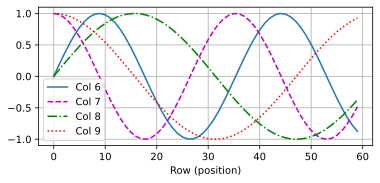

In [ ]:
encoding_dim, num_steps = 32, 60
pos_encoding = PositionalEncoding(encoding_dim, 0)
X = pos_encoding(torch.zeros((1, num_steps, encoding_dim)))
P = pos_encoding.P[:, :X.shape[1], :]
d2l.plot(torch.arange(num_steps), P[0, :, 6:10].T, xlabel='Row (position)',
         figsize=(6, 2.5), legend=["Col %d" % d for d in torch.arange(6, 10)])

#### 11.6.3.1. Absolute Positional Information

To see how the monotonically decreased frequency along the encoding dimension relates to absolute positional information, let's print out the binary representations of $0, 1, \ldots, 7$. As we can see, the lowest bit, the second-lowest bit, and the third-lowest bit alternate on every number, every two numbers, and every four numbers, respectively.

In [ ]:
for i in range(8):
    print(f'{i} in binary is {i:>03b}')

0 in binary is 000
1 in binary is 001
2 in binary is 010
3 in binary is 011
4 in binary is 100
5 in binary is 101
6 in binary is 110
7 in binary is 111


In binary representations, a higher bit has a lower frequency than a lower bit. Similarly, as demonstrated in the heat map below, the positional encoding decreases frequencies along the encoding dimension by using trigonometric functions. Since the outputs are float numbers, such continuous representations are more space-efficient than binary representations.

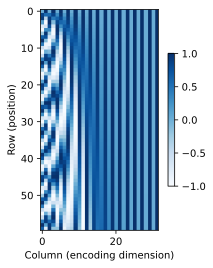

In [ ]:
P = P[0, :, :].unsqueeze(0).unsqueeze(0)
d2l.show_heatmaps(P, xlabel='Column (encoding dimension)',
                  ylabel='Row (position)', figsize=(3.5, 4), cmap='Blues')

#### 11.6.3.2. Relative Positional Information

Besides capturing absolute positional information, the above positional encoding also allows a model to easily learn to attend by relative positions. This is because for any fixed position offset $\delta$, the positional encoding at position $i + \delta$ can be represented by a linear projection of that at position $i$.

This projection can be explained mathematically. Denoting $\omega_j = 1/10000^{2j/d}$, any pair of $(p_{i, 2j}, p_{i, 2j+1})$ in (11.6.2) can be linearly projected to $(p_{i+\delta, 2j}, p_{i+\delta, 2j+1})$ for any fixed offset $\delta$:

$$\begin{aligned} \begin{bmatrix} \cos(\delta \omega_j) & \sin(\delta \omega_j) \\  -\sin(\delta \omega_j) & \cos(\delta \omega_j) \\ \end{bmatrix} \begin{bmatrix} p_{i, 2j} \\  p_{i, 2j+1} \\ \end{bmatrix} =&\begin{bmatrix} \cos(\delta \omega_j) \sin(i \omega_j) + \sin(\delta \omega_j) \cos(i \omega_j) \\  -\sin(\delta \omega_j) \sin(i \omega_j) + \cos(\delta \omega_j) \cos(i \omega_j) \\ \end{bmatrix}\\ =&\begin{bmatrix} \sin\left((i+\delta) \omega_j\right) \\  \cos\left((i+\delta) \omega_j\right) \\ \end{bmatrix}\\ =& \begin{bmatrix} p_{i+\delta, 2j} \\  p_{i+\delta, 2j+1} \\ \end{bmatrix}, \end{aligned} \tag{11.6.3}$$

where the $2\times 2$ projection matrix does not depend on any position index $i$.

### 11.6.4. Summary

In self-attention, the queries, keys, and values all come from the same place. Both CNNs and self-attention enjoy parallel computation and self-attention has the shortest maximum path length. However, the quadratic computational complexity with respect to the sequence length makes self-attention prohibitively slow for very long sequences. To use the sequence order information, we can inject absolute or relative positional information by adding positional encoding to the input representations.

### 11.6.5. Exercises

1. Suppose that we design a deep architecture to represent a sequence by stacking self-attention layers with positional encoding. What could the possible issues be?

1. Can you design a learnable positional encoding method?

1. Can we assign different learned embeddings according to different offsets between queries and keys that are compared in self-attention? Hint: you may refer to relative position embeddings (Huang et al., 2018, Shaw et al., 2018).

## 11.7. The Transformer Architecture

We have compared CNNs, RNNs, and self-attention in Section 11.6.2. Notably, self-attention enjoys both parallel computation and the shortest maximum path length. Therefore, it is appealing to design deep architectures by using self-attention. Unlike earlier self-attention models that still rely on RNNs for input representations (Cheng et al., 2016, Lin et al., 2017, Paulus et al., 2017), the Transformer model is solely based on attention mechanisms without any convolutional or recurrent layer (Vaswani et al., 2017). Though originally proposed for sequence-to-sequence learning on text data, Transformers have been pervasive in a wide range of modern deep learning applications, such as in areas to do with language, vision, speech, and reinforcement learning.

In [ ]:
import math
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

### 11.7.1. Model

As an instance of the encoder–decoder architecture, the overall architecture of the Transformer is presented in Fig. 11.7.1. As we can see, the Transformer is composed of an encoder and a decoder. In contrast to Bahdanau attention for sequence-to-sequence learning in Fig. 11.4.2, the input (source) and output (target) sequence embeddings are added with positional encoding before being fed into the encoder and the decoder that stack modules based on self-attention.

![](http://d2l.ai/_images/transformer.svg)
<center>Fig. 11.7.1 The Transformer architecture.</center>

Now we provide an overview of the Transformer architecture in Fig. 11.7.1. At a high level, the Transformer encoder is a stack of multiple identical layers, where each layer has two sublayers (either is denoted as $\textrm{sublayer}$). The first is a multi-head self-attention pooling and the second is a positionwise feed-forward network. Specifically, in the encoder self-attention, queries, keys, and values are all from the outputs of the previous encoder layer. Inspired by the ResNet design of Section 8.6, a residual connection is employed around both sublayers. In the Transformer, for any input $\mathbf{x} \in \mathbb{R}^d$ at any position of the sequence, we require that $\textrm{sublayer}(\mathbf{x}) \in \mathbb{R}^d$ so that the residual connection $\mathbf{x} + \textrm{sublayer}(\mathbf{x}) \in \mathbb{R}^d$ is feasible. This addition from the residual connection is immediately followed by layer normalization (Ba et al., 2016). As a result, the Transformer encoder outputs a $d$-dimensional vector representation for each position of the input sequence.

The Transformer decoder is also a stack of multiple identical layers with residual connections and layer normalizations. As well as the two sublayers described in the encoder, the decoder inserts a third sublayer, known as the encoder–decoder attention, between these two. In the encoder–decoder attention, queries are from the outputs of the decoder’s self-attention sublayer, and the keys and values are from the Transformer encoder outputs. In the decoder self-attention, queries, keys, and values are all from the outputs of the previous decoder layer. However, each position in the decoder is allowed only to attend to all positions in the decoder up to that position. This *masked* attention preserves the autoregressive property, ensuring that the prediction only depends on those output tokens that have been generated.

We have already described and implemented multi-head attention based on scaled dot products in Section 11.5 and positional encoding in Section 11.6.3. In the following, we will implement the rest of the Transformer model.

### 11.7.2. Positionwise Feed-Forward Networks

The positionwise feed-forward network transforms the representation at all the sequence positions using the same MLP. This is why we call it *positionwise*. In the implementation below, the input `X` with shape (batch size, number of time steps or sequence length in tokens, number of hidden units or feature dimension) will be transformed by a two-layer MLP into an output tensor of shape (batch size, number of time steps, `ffn_num_outputs`).

---
牧之：怎么理解 "This is why we call it positionwise"？

通义：在 Transformer 模型中，"positionwise" 这个术语指的是同一个位置前馈神经网络（Feed-Forward Network, FNN）对序列中所有位置的输入进行独立的、相同的操作。换句话说，对于序列中的每一个位置，都有一个独立的 FNN 分支对相应的表示进行处理，而这些 FNN 的结构和参数是共享的。

位置 FNN 通常由两个线性层（全连接层）组成，中间有一个非线性激活函数（如 ReLU）。第一个线性层将输入的隐藏状态映射到一个更大的中间层维度，然后激活函数应用于中间层的输出。第二个线性层再将激活后的中间层特征缩回到原始的隐藏状态维度。由于每个位置的输入都经历相同的 FNN 结构，所以称其为 "positionwise"。

使用 "positionwise" FNN 的优点在于，它允许每个位置独立地进行复杂的转换，而不依赖于其他位置的信息，同时也保持了计算的并行性。由于每个位置的 FNN 是相同的，所以可以在所有位置上同时执行，提高了计算效率。这种设计是 Transformer 架构的关键组成部分，帮助模型学习序列中的复杂模式，而无需依赖于 RNNs 的顺序处理。

In [ ]:
class PositionWiseFFN(nn.Module):  #@ save
    """The positionwise feed-forward network."""
    def __init__(self, ffn_num_hiddens, ffn_num_outputs):
        super().__init__()
        self.dense1 = nn.LazyLinear(ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.LazyLinear(ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

The following example shows that the innermost dimension of a tensor changes to the number of outputs in the positionwise feed-forward network. Since the same MLP transforms at all the positions, when the inputs at all these positions are the same, their outputs are also identical.

In [ ]:
ffn = PositionWiseFFN(4, 8)
ffn.eval()
ffn(torch.ones((2, 3, 4)))[0]

tensor([[ 0.5726,  0.1581, -0.4620,  0.1888, -0.2982,  0.6956,  0.2903,  0.3722],
        [ 0.5726,  0.1581, -0.4620,  0.1888, -0.2982,  0.6956,  0.2903,  0.3722],
        [ 0.5726,  0.1581, -0.4620,  0.1888, -0.2982,  0.6956,  0.2903,  0.3722]],
       grad_fn=<SelectBackward0>)

### 11.7.3. Residual Connection and Layer Normalization

Now let’s focus on the “add & norm” component in Fig. 11.7.1. As we described at the beginning of this section, this is a residual connection immediately followed by layer normalization. Both are key to effective deep architectures.

In Section 8.5, we explained how batch normalization recenters and rescales across the examples within a minibatch. As discussed in Section 8.5.2.3, layer normalization is the same as batch normalization except that the former normalizes across the feature dimension, thus enjoying benefits of scale independence and batch size independence. Despite its pervasive applications in computer vision, batch normalization is usually empirically less effective than layer normalization in natural language processing tasks, where the inputs are often variable-length sequences.

The following code snippet compares the normalization across different dimensions by layer normalization and batch normalization.

In [ ]:
ln = nn.LayerNorm(2)
bn = nn.LazyBatchNorm1d()
X = torch.tensor([[1, 2], [2, 3]], dtype=torch.float32)
# Compute mean and variance from X in the training mode
print('layer norm:', ln(X), '\nbatch norm:', bn(X))

layer norm: tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]], grad_fn=<NativeLayerNormBackward0>) 
batch norm: tensor([[-1.0000, -1.0000],
        [ 1.0000,  1.0000]], grad_fn=<NativeBatchNormBackward0>)


Now we can implement the `AddNorm` class using a residual connection followed by layer normalization. Dropout is also applied for regularization.

In [ ]:
class AddNorm(nn.Module):  #@ save
    """The residual connection followed by layer normalization."""
    def __init__(self, norm_shape, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(norm_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

The residual connection requires that the two inputs are of the same shape so that the output tensor also has the same shape after the addition operation.

In [ ]:
add_norm = AddNorm(4, 0.5)
shape = (2, 3, 4)
d2l.check_shape(add_norm(torch.ones(shape), torch.ones(shape)), shape)

### 11.7.4. Encoder

With all the essential components to assemble the Transformer encoder, let's start by implementing a single layer within the encoder. The following `TransformerEncoderBlock` class contains two sublayers: multi-head self-attention and positionwise feed-forward networks, where a residual connection followed by layer normalization is employed around both sublayers.

In [ ]:
class TransformerEncoderBlock(nn.Module):  #@ save
    """The Transformer encoder block."""
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout,
                 use_bias=False):
        super().__init__()
        self.attention = d2l.MultiHeadAttention(num_hiddens, num_heads,
                                                dropout, use_bias)
        self.addnorm1 = AddNorm(num_hiddens, dropout)
        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(num_hiddens, dropout)

    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

As we can see, no layer in the Transformer encoder changes the shape of its input.

In [ ]:
X = torch.ones((2, 100, 24))
valid_lens = torch.tensor([3, 2])
encoder_blk = TransformerEncoderBlock(24, 48, 8, 0.5)
encoder_blk.eval()
d2l.check_shape(encoder_blk(X, valid_lens), X.shape)

In the following Transformer encoder implementation, we stack `num_blks` instances of the above `TransformerEncoderBlock` classes. Since we use the fixed positional encoding whose values are always between $-1$ and $1$, we multiply values of the learnable input embeddings by the square root of the embedding dimension to rescale before summing up the input embedding and the positional encoding.

---
通义：这段描述是在解释如何在 Transformer 编码器中融合学习到的输入嵌入（learnable input embeddings）和固定的位移编码（positional encoding）。位移编码是预先计算好的，它的值通常在 -1 和 1 之间，目的是为序列中的每个位置提供独特的表示，帮助模型捕捉序列的顺序信息。

在 Transformer 中，输入通常是通过一个可学习的词嵌入层转换的，该层将词汇的索引映射到高维空间的向量。这些学习到的嵌入（input embeddings）的大小与位移编码相同，但它们的值在训练过程中是可以改变的。为了在添加位移编码之前平衡这两种类型的编码，我们需要对学习到的嵌入进行尺度调整（rescaling）。

为什么要进行这种调整呢？这是因为位移编码是固定的，其值域是预先定义的，而学习到的嵌入可能会有较大的变化范围。如果不进行调整，学习到的嵌入可能会比位移编码强得多，导致模型过分依赖学习到的嵌入，忽视了位移编码提供的顺序信息。另一方面，如果位移编码太强，可能会阻碍学习到的嵌入的适应性。

因此，我们乘以嵌入维度的平方根来进行调整，这个操作通常被称为“根尺度”（root scaling）。这有助于保持两种编码的相对强度，让它们在训练过程中能协同工作，共同影响模型的学习。这样，Transformer 编码器就能充分利用两种类型的编码，既能学习到词汇的语义信息，又能捕捉到序列的顺序结构。

In [ ]:
class TransformerEncoder(d2l.Encoder):  #@ save
    """The Transformer encoder."""
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens,
                 num_heads, num_blks, dropout, use_bias=False):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module("block"+str(i), TransformerEncoderBlock(
                num_hiddens, ffn_num_hiddens, num_heads, dropout, use_bias))

    def forward(self, X, valid_lens):
        # Since positional encoding values are between -1 and 1, the embedding
        # values are multiplied by the square root of the embedding dimension
        # to rescale before they are summed up
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * len(self.blks)
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            self.attention_weights[
                i] = blk.attention.attention.attention_weights
        return X

Below we specify hyperparameters to create a two-layer Transformer encoder. The shape of the Transformer encoder output is (batch size, number of time steps, num_hiddens).

In [ ]:
encoder = TransformerEncoder(200, 24, 48, 8, 2, 0.5)
d2l.check_shape(encoder(torch.ones((2, 100), dtype=torch.long), valid_lens),
                (2, 100, 24))

### 11.7.5. Decoder

As shown in Fig. 11.7.1, the Transformer decoder is composed of multiple identical layers. Each layer is implemented in the following `TransformerDecoderBlock` class, which contains three sublayers: decoder self-attention, encoder--decoder attention, and positionwise feed-forward networks. These sublayers employ a residual connection around them followed by layer normalization.

As we described earlier in this section, in the masked multi-head decoder self-attention (the first sublayer), queries, keys, and values all come from the outputs of the previous decoder layer. When training sequence-to-sequence models, tokens at all the positions (time steps) of the output sequence are known. However, during prediction the output sequence is generated token by token; thus, at any decoder time step only the generated tokens can be used in the decoder self-attention. To preserve autoregression in the decoder, its masked self-attention specifies  `dec_valid_lens` so that any query only attends to all positions in the decoder up to the query position.

In [ ]:
class TransformerDecoderBlock(nn.Module):
    # The i-th block in the Transformer decoder
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout, i):
        super().__init__()
        self.i = i
        self.attention1 = d2l.MultiHeadAttention(num_hiddens, num_heads,
                                                 dropout)
        self.addnorm1 = AddNorm(num_hiddens, dropout)
        self.attention2 = d2l.MultiHeadAttention(num_hiddens, num_heads,
                                                 dropout)
        self.addnorm2 = AddNorm(num_hiddens, dropout)
        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)
        self.addnorm3 = AddNorm(num_hiddens, dropout)

    def forward(self, X, state):
        enc_outputs, enc_valid_lens = state[0], state[1]
        # During training, all the tokens of any output sequence are processed
        # at the same time, so state[2][self.i] is None as initialized. When
        # decoding any output sequence token by token during prediction,
        # state[2][self.i] contains representations of the decoded output at
        # the i-th block up to the current time step
        if state[2][self.i] is None:
            key_values = X
        else:
            key_values = torch.cat((state[2][self.i], X), dim=1)
        state[2][self.i] = key_values
        if self.training:
            batch_size, num_steps, _ = X.shape
            # Shape of dec_valid_lens: (batch_size, num_steps), where every
            # row is [1, 2, ..., num_steps]
            dec_valid_lens = torch.arange(
                1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        else:
            dec_valid_lens = None
        # Self-attention
        X2 = self.attention1(X, key_values, key_values, dec_valid_lens)
        Y = self.addnorm1(X, X2)
        # Encoder-decoder attention. Shape of enc_outputs:
        # (batch_size, num_steps, num_hiddens)
        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)
        return self.addnorm3(Z, self.ffn(Z)), state

To facilitate scaled dot product operations in the encoder–decoder attention and addition operations in the residual connections, the feature dimension (`num_hiddens`) of the decoder is the same as that of the encoder.

In [ ]:
decoder_blk = TransformerDecoderBlock(24, 48, 8, 0.5, 0)
X = torch.ones((2, 100, 24))
state = [encoder_blk(X, valid_lens), valid_lens, [None]]
d2l.check_shape(decoder_blk(X, state)[0], X.shape)

Now we construct the entire Transformer decoder composed of `num_blks` instances of `TransformerDecoderBlock`. In the end, a fully connected layer computes the prediction for all the `vocab_size` possible output tokens. Both of the decoder self-attention weights and the encoder--decoder attention weights are stored for later visualization.

In [ ]:
class TransformerDecoder(d2l.AttentionDecoder):
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens, num_heads,
                 num_blks, dropout):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.num_blks = num_blks
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module("block"+str(i), TransformerDecoderBlock(
                num_hiddens, ffn_num_hiddens, num_heads, dropout, i))
        self.dense = nn.LazyLinear(vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens):
        return [enc_outputs, enc_valid_lens, [None] * self.num_blks]

    def forward(self, X, state):
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self._attention_weights = [[None] * len(self.blks) for _ in range (2)]
        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)
            # Decoder self-attention weights
            self._attention_weights[0][
                i] = blk.attention1.attention.attention_weights
            # Encoder-decoder attention weights
            self._attention_weights[1][
                i] = blk.attention2.attention.attention_weights
        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights

### 11.7.6. Training

Let’s instantiate an encoder–decoder model by following the Transformer architecture. Here we specify that both the Transformer encoder and the Transformer decoder have two layers using 4-head attention. As in Section 10.7.6, we train the Transformer model for sequence-to-sequence learning on the English–French machine translation dataset.

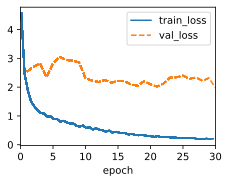

In [ ]:
data = d2l.MTFraEng(batch_size=128)
num_hiddens, num_blks, dropout = 256, 2, 0.2
ffn_num_hiddens, num_heads = 64, 4
encoder = TransformerEncoder(
    len(data.src_vocab), num_hiddens, ffn_num_hiddens, num_heads,
    num_blks, dropout)
decoder = TransformerDecoder(
    len(data.tgt_vocab), num_hiddens, ffn_num_hiddens, num_heads,
    num_blks, dropout)
model = d2l.Seq2Seq(encoder, decoder, tgt_pad=data.tgt_vocab['<pad>'],
                    lr=0.001)
trainer = d2l.Trainer(max_epochs=30, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

After training, we use the Transformer model to translate a few English sentences into French and compute their BLEU scores.

In [ ]:
engs = ['go .', 'i lost .', 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
preds, _ = model.predict_step(
    data.build(engs, fras), d2l.try_gpu(), data.num_steps)
for en, fr, p in zip(engs, fras, preds):
    translation = []
    for token in data.tgt_vocab.to_tokens(p):
        if token == '<eos>':
            break
        translation.append(token)
    print(f'{en} => {translation}, bleu,'
          f'{d2l.bleu(" ".join(translation), fr, k=2):.3f}')

go . => ['va', '!'], bleu,1.000
i lost . => ["j'ai", 'perdu', '.'], bleu,1.000
he's calm . => ['il', 'est', 'mouillé', '.'], bleu,0.658
i'm home . => ['je', 'suis', 'chez', 'moi', '.'], bleu,1.000


Let's visualize the Transformer attention weights when translating the final English sentence into French. The shape of the encoder self-attention weights is (number of encoder layers, number of attention heads, `num_steps` or number of queries, `num_steps` or number of key-value pairs).

In [ ]:
_, dec_attention_weights = model.predict_step(
    data.build([engs[-1]], [fras[-1]]), d2l.try_gpu(), data.num_steps, True)
enc_attention_weights = torch.cat(model.encoder.attention_weights, 0)
shape = (num_blks, num_heads, -1, data.num_steps)
enc_attention_weights = enc_attention_weights.reshape(shape)
d2l.check_shape(enc_attention_weights,
                (num_blks, num_heads, data.num_steps, data.num_steps))

In the encoder self-attention, both queries and keys come from the same input sequence. Since padding tokens do not carry meaning, with specified valid length of the input sequence no query attends to positions of padding tokens. In the following, two layers of multi-head attention weights are presented row by row. Each head independently attends based on a separate representation subspace of queries, keys, and values.

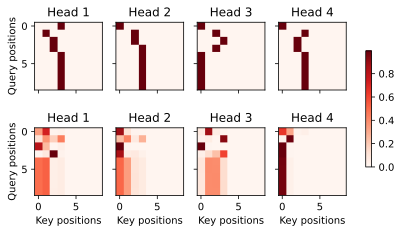

In [ ]:
d2l.show_heatmaps(
    enc_attention_weights.cpu(), xlabel='Key positions',
    ylabel='Query positions', titles=['Head %d' % i for i in range(1, 5)],
    figsize=(7, 3.5))

To visualize the decoder self-attention weights and the encoder–decoder attention weights, we need more data manipulations. For example, we fill the masked attention weights with zero. Note that the decoder self-attention weights and the encoder–decoder attention weights both have the same queries: the beginning-of-sequence token followed by the output tokens and possibly end-of-sequence tokens.

In [ ]:
dec_attention_weights_2d = [head[0].tolist()
                            for step in dec_attention_weights
                            for attn in step for blk in attn for head in blk]
dec_attention_weights_filled = torch.tensor(
    pd.DataFrame(dec_attention_weights_2d).fillna(0.0).values)
shape = (-1, 2, num_blks, num_heads, data.num_steps)
dec_attention_weights = dec_attention_weights_filled.reshape(shape)
dec_self_attention_weights, dec_inter_attention_weights = \
    dec_attention_weights.permute(1, 2, 3, 0, 4)

d2l.check_shape(dec_self_attention_weights,
                (num_blks, num_heads, data.num_steps, data.num_steps))
d2l.check_shape(dec_inter_attention_weights,
                (num_blks, num_heads, data.num_steps, data.num_steps))

Because of the autoregressive property of the decoder self-attention, no query attends to key–value pairs after the query position.

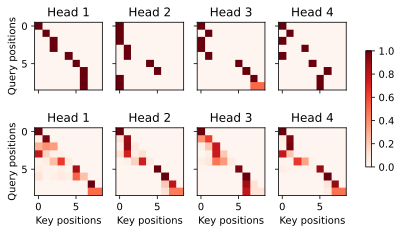

In [ ]:
d2l.show_heatmaps(
    dec_self_attention_weights[:, :, :, :],
    xlabel='Key positions', ylabel='Query positions',
    titles=['Head %d' % i for i in range(1, 5)], figsize=(7, 3.5))

Similar to the case in the encoder self-attention, via the specified valid length of the input sequence, no query from the output sequence attends to those padding tokens from the input sequence.

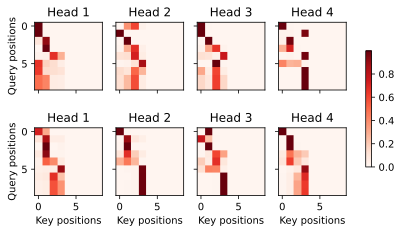

In [ ]:
d2l.show_heatmaps(
    dec_inter_attention_weights, xlabel='Key positions',
    ylabel='Query positions', titles=['Head %d' % i for i in range(1, 5)],
    figsize=(7, 3.5))

Although the Transformer architecture was originally proposed for sequence-to-sequence learning, as we will discover later in the book, either the Transformer encoder or the Transformer decoder is often individually used for different deep learning tasks.

### 11.7.7. Summary

The Transformer is an instance of the encoder–decoder architecture, though either the encoder or the decoder can be used individually in practice. In the Transformer architecture, multi-head self-attention is used for representing the input sequence and the output sequence, though the decoder has to preserve the autoregressive property via a masked version. Both the residual connections and the layer normalization in the Transformer are important for training a very deep model. The positionwise feed-forward network in the Transformer model transforms the representation at all the sequence positions using the same MLP.

### 11.7.8. Exercises

1. Train a deeper Transformer in the experiments. How does it affect the training speed and the translation performance?

1. Is it a good idea to replace scaled dot product attention with additive attention in the Transformer? Why?

1. For language modeling, should we use the Transformer encoder, decoder, or both? How would you design this method?

1. What challenges can Transformers face if input sequences are very long? Why?

1. How would you improve the computational and memory efficiency of Transformers? Hint: you may refer to the survey paper by Tay et al. (2020).

## 11.8. Transformers for Vision

Without specific constraints on patch size, *vision Transformers* (ViTs) extract patches from images and feed them into a Transformer encoder to obtain a global representation, which will finally be transformed for classification (Dosovitskiy et al., 2021). Notably, Transformers show better scalability than CNNs: and when training larger models on larger datasets, vision Transformers outperform ResNets by a significant margin. Similar to the landscape of network architecture design in natural language processing, Transformers have also become a game-changer in computer vision.

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

### 11.8.1. Model

Fig. 11.8.1 depicts the model architecture of vision Transformers. This architecture consists of a stem that patchifies images, a body based on the multilayer Transformer encoder, and a head that transforms the global representation into the output label.

![](http://d2l.ai/_images/vit.svg)
<center>Fig. 11.8.1 The vision Transformer architecture. In this example, an image is split into nine patches. A special “&lt;cls&gt;” token and the nine flattened image patches are transformed via patch embedding and $\mathit{n}$ Transformer encoder blocks into ten representations, respectively. The “&lt;cls&gt;” representation is further transformed into the output label.</center>

Consider an input image with height $h$, width $w$, and $c$ channels. Specifying the patch height and width both as $p$, the image is split into a sequence of $m = hw/p^2$ patches, where each patch is flattened to a vector of length $cp^2$. In this way, image patches can be treated similarly to tokens in text sequences by Transformer encoders. A special “&lt;cls&gt;” (class) token and the $m$ flattened image patches are linearly projected into a sequence of $m+1$ vectors, summed with learnable positional embeddings. The multilayer Transformer encoder transforms $m+1$ input vectors into the same number of output vector representations of the same length. It works exactly the same way as the original Transformer encoder in Fig. 11.7.1, only differing in the position of normalization. Since the “&lt;cls&gt;” token attends to all the image patches via self-attention (see Fig. 11.6.1), its representation from the Transformer encoder output will be further transformed into the output label.

### 11.8.2. Patch Embedding

To implement a vision Transformer, let’s start with patch embedding in Fig. 11.8.1. Splitting an image into patches and linearly projecting these flattened patches can be simplified as a single convolution operation, where both the kernel size and the stride size are set to the patch size.

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=96, patch_size=16, num_hiddens=512):
        super().__init__()
        def _make_tuple(x):
            if not isinstance(x, (list, tuple)):
                return (x, x)
            return x
        img_size, patch_size = _make_tuple(img_size), _make_tuple(patch_size)
        self.num_patches = (img_size[0] // patch_size[0]) * (
            img_size[1] // patch_size[1])
        self.conv = nn.LazyConv2d(num_hiddens, kernel_size=patch_size,
                                  stride=patch_size)

    def forward(self, X):
        # Output shape: (batch size, no. of patches, no. of channels)
        return self.conv(X).flatten(2).transpose(1, 2)

In the following example, taking images with height and width of `img_size` as inputs, the patch embedding outputs `(img_size//patch_size)**2` patches that are linearly projected to vectors of length `num_hiddens`.

In [ ]:
img_size, patch_size, num_hiddens, batch_size = 96, 16, 512, 4
patch_emb = PatchEmbedding(img_size, patch_size, num_hiddens)
X = torch.zeros(batch_size, 3, img_size, img_size)
d2l.check_shape(patch_emb(X),
                (batch_size, (img_size//patch_size)**2, num_hiddens))

### 11.8.3. Vision Transformer Encoder

The MLP of the vision Transformer encoder is slightly different from the positionwise FFN of the original Transformer encoder (see Section 11.7.2). First, here the activation function uses the Gaussian error linear unit (GELU), which can be considered as a smoother version of the ReLU (Hendrycks and Gimpel, 2016). Second, dropout is applied to the output of each fully connected layer in the MLP for regularization.

In [ ]:
class ViTMLP(nn.Module):
    def __init__(self, mlp_num_hiddens, mlp_num_outputs, dropout=0.5):
        super().__init__()
        self.dense1 = nn.LazyLinear(mlp_num_hiddens)
        self.gelu = nn.GELU()
        self.dropout1 = nn.Dropout(dropout)
        self.dense2 = nn.LazyLinear(mlp_num_outputs)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout2(self.dense2(self.dropout1(self.gelu(
            self.dense1(x)))))

The vision Transformer encoder block implementation just follows the pre-normalization design in Fig. 11.8.1, where normalization is applied right *before* multi-head attention or the MLP. In contrast to post-normalization (“add & norm” in Fig. 11.7.1), where normalization is placed right *after* residual connections, pre-normalization leads to more effective or efficient training for Transformers (Baevski and Auli, 2018, Wang et al., 2019, Xiong et al., 2020).

In [ ]:
class ViTBlock(nn.Module):
    def __init__(self, num_hiddens, norm_shape, mlp_num_hiddens,
                 num_heads, dropout, use_bias=False):
        super().__init__()
        self.ln1 = nn.LayerNorm(norm_shape)
        self.attention = d2l.MultiHeadAttention(num_hiddens, num_heads,
                                                dropout, use_bias)
        self.ln2 = nn.LayerNorm(norm_shape)
        self.mlp = ViTMLP(mlp_num_hiddens, num_hiddens, dropout)

    def forward(self, X, valid_lens=None):
        X = X + self.attention(*([self.ln1(X)] * 3), valid_lens)
        return X + self.mlp(self.ln2(X))

Just as in Section 11.7.4, no vision Transformer encoder block changes its input shape.

In [ ]:
X = torch.ones((2, 100, 24))
encoder_blk = ViTBlock(24, 24, 48, 8, 0.5)
encoder_blk.eval()
d2l.check_shape(encoder_blk(X), X.shape)

### 11.8.4. Putting It All Together

The forward pass of vision Transformers below is straightforward. First, input images are fed into an `PatchEmbedding` instance, whose output is concatenated with the “&lt;cls&gt;”  token embedding. They are summed with learnable positional embeddings before dropout. Then the output is fed into the Transformer encoder that stacks `num_blks` instances of the `ViTBlock` class. Finally, the representation of the “&lt;cls&gt;”  token is projected by the network head.

In [ ]:
class ViT(d2l.Classifier):
    """Vision Transformer."""
    def __init__(self, img_size, patch_size, num_hiddens, mlp_num_hiddens,
                 num_heads, num_blks, emb_dropout, blk_dropout, lr=0.1,
                 use_bias=False, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.patch_embedding = PatchEmbedding(
            img_size, patch_size, num_hiddens)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, num_hiddens))
        num_steps = self.patch_embedding.num_patches + 1  # Add the cls token
        # Positional embeddings are learnable
        self.pos_embedding = nn.Parameter(
            torch.randn(1, num_steps, num_hiddens))
        self.dropout = nn.Dropout(emb_dropout)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module(f"{i}", ViTBlock(
                num_hiddens, num_hiddens, mlp_num_hiddens,
                num_heads, blk_dropout, use_bias))
        self.head = nn.Sequential(nn.LayerNorm(num_hiddens),
                                  nn.Linear(num_hiddens, num_classes))

    def forward(self, X):
        X = self.patch_embedding(X)
        X = torch.cat((self.cls_token.expand(X.shape[0], -1, -1), X), 1)
        X = self.dropout(X + self.pos_embedding)
        for blk in self.blks:
            X = blk(X)
        return self.head(X[:, 0])

### 11.8.5. Training

Training a vision Transformer on the Fashion-MNIST dataset is just like how CNNs were trained in Section 8.

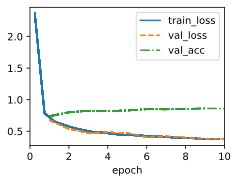

In [ ]:
img_size, patch_size = 96, 16
num_hiddens, mlp_num_hiddens, num_heads, num_blks = 512, 2048, 8, 2
emb_dropout, blk_dropout, lr = 0.1, 0.1, 0.1
model = ViT(img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads,
            num_blks, emb_dropout, blk_dropout, lr)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(img_size, img_size))
trainer.fit(model, data)

### 11.8.6. Summary and Discussion

You may have noticed that for small datasets like Fashion-MNIST, our implemented vision Transformer does not outperform the ResNet in Section 8.6. Similar observations can be made even on the ImageNet dataset (1.2 million images). This is because Transformers *lack* those useful principles in convolution, such as translation invariance and locality (Section 7.1). However, the picture changes when training larger models on larger datasets (e.g., 300 million images), where vision Transformers outperform ResNets by a large margin in image classification, demonstrating intrinsic superiority of Transformers in scalability (Dosovitskiy et al., 2021). The introduction of vision Transformers has changed the landscape of network design for modeling image data. They were soon shown to be effective on the ImageNet dataset with data-efficient training strategies of DeiT (Touvron et al., 2021). However, the quadratic complexity of self-attention (Section 11.6) makes the Transformer architecture less suitable for higher-resolution images. Towards a general-purpose backbone network in computer vision, Swin Transformers addressed the quadratic computational complexity with respect to image size (Section 11.6.2) and reinstated convolution-like priors, extending the applicability of Transformers to a range of computer vision tasks beyond image classification with state-of-the-art results (Liu et al., 2021).

### 11.8.7. Exercises

1. How does the value of `img_size` affect training time?

1. Instead of projecting the “&lt;cls&gt;” token representation to the output, how would you project the averaged patch representations? Implement this change and see how it affects the accuracy.

1. Can you modify hyperparameters to improve the accuracy of the vision Transformer?

## 11.9. Large-Scale Pretraining with Transformers

So far in our image classification and machine translation experiments, models have been trained on datasets with input–output examples *from scratch* to perform specific tasks. For example, a Transformer was trained with English–French pairs (Section 11.7) so that this model can translate input English text into French. As a result, each model becomes a *specific expert* that is sensitive to even a slight shift in data distribution (Section 4.7). For better generalized models, or even more competent *generalists* that can perform multiple tasks with or without adaptation, *pretraining* models on large data has been increasingly common.

Given larger data for pretraining, the Transformer architecture performs better with an increased model size and training compute, demonstrating superior *scaling* behavior. Specifically, performance of Transformer-based language models scales as a power law with the amount of model parameters, training tokens, and training compute (Kaplan et al., 2020). The scalability of Transformers is also evidenced by the significantly boosted performance from larger vision Transformers trained on larger data (discussed in Section 11.8). More recent success stories include Gato, a *generalist* model that can play Atari, caption images, chat, and act as a robot (Reed et al., 2022). Gato is a single Transformer that scales well when pretrained on diverse modalities, including text, images, joint torques, and button presses. Notably, all such multimodal data is serialized into a flat sequence of tokens, which can be processed akin to text tokens (Section 11.7) or image patches (Section 11.8) by Transformers.

Prior to the compelling success of pretraining Transformers for multimodal data, Transformers were extensively pretrained with a wealth of text. Originally proposed for machine translation, the Transformer architecture in Fig. 11.7.1 consists of an encoder for representing input sequences and a decoder for generating target sequences. Primarily, Transformers can be used in three different modes: *encoder-only*, *encoder–decoder*, and *decoder-only*. To conclude this chapter, we will review these three modes and explain the scalability in pretraining Transformers.

### 11.9.1. Encoder-Only

When only the Transformer encoder is used, a sequence of input tokens is converted into the same number of representations that can be further projected into output (e.g., classification). A Transformer encoder consists of  self-attention layers, where all input tokens attend to each other. For example, vision Transformers depicted in Fig. 11.8.1 are encoder-only, converting a sequence of input image patches into the representation of a special “&lt;cls&gt;” token. Since this representation depends on all input tokens, it is further projected into classification labels. This design was inspired by an earlier encoder-only Transformer pretrained on text: BERT (Bidirectional Encoder Representations from Transformers) (Devlin et al., 2018).

#### 11.9.1.1. Pretraining BERT

![](https://d2l.ai/_images/bert-encoder-only.svg)
<center>Fig. 11.9.1 Left: Pretraining BERT with masked language modeling. Prediction of the masked "love" token depends on all input tokens before and after "love". Right: Attention pattern in the Transformer encoder. Each token along the vertical axis attends to all input tokens along the horizontal axis.</center>

BERT is pretrained on text sequences using *masked language modeling*: input text with randomly masked tokens is fed into a Transformer encoder to predict the masked tokens. As illustrated in :numref:`fig_bert-encoder-only`, an original text sequence "I", "love", "this", "red", "car" is prepended with the “&lt;cls&gt;” token, and the “&lt;mask&gt;” token randomly replaces "love"; then the cross-entropy loss between the masked token "love" and its prediction is to be minimized during pretraining. Note that there is no constraint in the attention pattern of Transformer encoders (right of :numref:`fig_bert-encoder-only`) so all tokens can attend to each other. Thus, prediction of "love" depends on input tokens before and after it in the sequence. This is why BERT is a "bidirectional encoder". Without need for manual labeling, large-scale text data from books and Wikipedia can be used for pretraining BERT.

#### 11.9.1.2. Fine-Tuning BERT

The pretrained BERT can be *fine-tuned* to downstream encoding tasks involving single text or text pairs. During fine-tuning, additional layers can be added to BERT with randomized parameters: these parameters and those pretrained BERT parameters will be *updated* to fit training data of downstream tasks.

![](https://d2l.ai/_images/bert-finetune-classification.svg)
<center>Fig. 11.9.2 Fine-tuning BERT for sentiment analysis.</center>

Fig. 11.9.2 illustrates fine-tuning of BERT for sentiment analysis. The Transformer encoder is a pretrained BERT, which takes a text sequence as input and feeds the “&lt;cls&gt;” representation (global representation of the input) into an additional fully connected layer to predict the sentiment. During fine-tuning, the cross-entropy loss between the prediction and the label on sentiment analysis data is minimized via gradient-based algorithms, where the additional layer is trained from scratch while pretrained parameters of BERT are updated. BERT does more than sentiment analysis. The general language representations learned by the 350-million-parameter BERT from 250 billion training tokens advanced the state of the art for natural language tasks such as single text classification, text pair classification or regression, text tagging, and question answering.

You may note that these downstream tasks include text pair understanding. BERT pretraining has another loss for predicting whether one sentence immediately follows the other. However, this loss was later found to be less useful when pretraining RoBERTa, a BERT variant of the same size, on 2000 billion tokens (Liu et al., 2019). Other derivatives of BERT improved model architectures or pretraining objectives, such as ALBERT (enforcing parameter sharing) (Lan et al., 2019), SpanBERT (representing and predicting spans of text) (Joshi et al., 2020), DistilBERT (lightweight via knowledge distillation) (Sanh et al., 2019), and ELECTRA (replaced token detection) (Clark et al., 2020). Moreover, BERT inspired Transformer pretraining in computer vision, such as with vision Transformers (Dosovitskiy et al., 2021), Swin Transformers (Liu et al., 2021), and MAE (masked autoencoders) (He et al., 2022).

### 11.9.2. Encoder–Decoder

Since a Transformer encoder converts a sequence of input tokens into the same number of output representations, the encoder-only mode cannot generate a sequence of arbitrary length as in machine translation. As originally proposed for machine translation, the Transformer architecture can be outfitted with a decoder that autoregressively predicts the target sequence of arbitrary length, token by token, conditional on both encoder output and decoder output: (i) for conditioning on encoder output, encoder–decoder cross-attention (multi-head attention of decoder in Fig. 11.7.1) allows target tokens to attend to *all* input tokens; (ii) conditioning on decoder output is achieved by a so-called *causal* attention (this name is common in the literature but is misleading as it has little connection to the proper study of causality) pattern (masked multi-head attention of decoder in Fig. 11.7.1), where any target token can only attend to *past* and *present* tokens in the target sequence.

To pretrain encoder–decoder Transformers beyond human-labeled machine translation data, BART (Lewis et al., 2019) and T5 (Raffel et al., 2020) are two concurrently proposed encoder–decoder Transformers pretrained on large-scale text corpora. Both attempt to reconstruct original text in their pretraining objectives, while the former emphasizes noising input (e.g., masking, deletion, permutation, and rotation) and the latter highlights multitask unification with comprehensive ablation studies.

#### 11.9.2.1. Pretraining T5

As an example of the pretrained Transformer encoder--decoder, T5 (Text-to-Text Transfer Transformer) unifies many tasks as the same text-to-text problem: for any task, the input of the encoder is a task description (e.g., "Summarize", ":") followed by task input (e.g., a sequence of tokens from an article), and the decoder predicts the task output (e.g., a sequence of tokens summarizing the input article). To perform as text-to-text, T5 is trained to generate some target text conditional on input text.

![](https://d2l.ai/_images/t5-encoder-decoder.svg)
<center>Fig. 11.9.3 Left: Pretraining T5 by predicting consecutive spans. The original sentence is "I", "love", "this", "red", "car", where "love" is replaced by a special “&lt;X&gt;” token, and consecutive "red", "car" are replaced by a special “&lt;Y&gt;” token. The target sequence ends with a special “&lt;Z&gt;” token. Right: Attention pattern in the Transformer encoder--decoder. In the encoder self-attention (lower square), all input tokens attend to each other; In the encoder--decoder cross-attention (upper rectangle), each target token attends to all input tokens; In the decoder self-attention (upper triangle), each target token  attends to present and past target tokens only (causal).</center>

To obtain input and output from any original text, T5 is pretrained to predict consecutive spans. Specifically, tokens from text are randomly replaced by special tokens where each consecutive span is replaced by the same special token. Consider the example in :numref:`fig_t5-encoder-decoder`, where the original text is "I", "love", "this", "red", "car". Tokens "love", "red", "car" are randomly replaced by special tokens. Since "red" and "car" are a consecutive span, they are replaced by the same special token. As a result, the input sequence is "I", "&lt;X&gt;", "this", "&lt;Y&gt;", and the target sequence is "&lt;X&gt;", "love", "&lt;Y&gt;", "red", "car", "&lt;Z&gt;", where "&lt;Z&gt;" is another special token marking the end. As shown in :numref:`fig_t5-encoder-decoder`, the decoder has a causal attention pattern to prevent itself from attending to future tokens during sequence prediction.

In T5, predicting consecutive span is also referred to as reconstructing corrupted text. With this objective, T5 is pretrained with 1000 billion tokens from the C4 (Colossal Clean Crawled Corpus) data, which consists of clean English text from the web (Raffel et al., 2020).

#### 11.9.2.2. Fine-Tuning T5

Similar to BERT, T5 needs to be fine-tuned (updating T5 parameters) on task-specific training data to perform this task. Major differences from BERT fine-tuning include: (i) T5 input includes task descriptions; (ii) T5 can generate sequences with arbitrary length with its Transformer decoder; (iii) No additional layers are required.

![](https://d2l.ai/_images/t5-finetune-summarization.svg)
<center>Fig. 11.9.4 Fine-tuning T5 for text summarization. Both the task description and article tokens are fed into the Transformer encoder for predicting the summary.</center>

Fig. 11.9.4 explains fine-tuning T5 using text summarization as an example. In this downstream task, the task description tokens "Summarize", ":" followed by the article tokens are input to the encoder.

After fine-tuning, the 11-billion-parameter T5 (T5-11B) achieved state-of-the-art results on multiple encoding (e.g., classification) and generation (e.g., summarization) benchmarks. Since released, T5 has been extensively used in later research. For example, switch Transformers are designed based on T5 to activate a subset of the parameters for better computational efficiency (Fedus et al., 2022). In a text-to-image model called Imagen, text is input to a frozen T5 encoder (T5-XXL) with 4.6 billion parameters (Saharia et al., 2022). The photorealistic text-to-image examples in Fig. 11.9.5 suggest that the T5 encoder alone may effectively represent text even without fine-tuning.

![).](https://d2l.ai/_images/imagen.png)
<center>Fig. 11.9.5 Text-to-image examples by the Imagen model, whose text encoder is from T5 (figures taken from Saharia et al. (2022)).</center>

### 11.9.3. Decoder-Only

We have reviewed encoder-only and encoder–decoder Transformers. Alternatively, decoder-only Transformers remove the entire encoder and the decoder sublayer with the encoder–decoder cross-attention from the original encoder–decoder architecture depicted in Fig. 11.7.1. Nowadays, decoder-only Transformers have been the *de facto* architecture in large-scale language modeling (Section 9.3), which leverages the world’s abundant unlabeled text corpora via self-supervised learning.

#### 11.9.3.1. GPT and GPT-2

Using language modeling as the training objective, the GPT (generative pre-training) model chooses a Transformer decoder as its backbone (Radford et al., 2018).

![](https://d2l.ai/_images/gpt-decoder-only.svg)
<center>Fig. 11.9.6 Left: Pretraining GPT with language modeling. The target sequence is the input sequence shifted by one token. Both “&lt;bos&gt;” and “&lt;eos&gt;” are special tokens marking the beginning and end of sequences, respectively. Right: Attention pattern in the Transformer decoder. Each token along the vertical axis attends to only its past tokens along the horizontal axis (causal).</center>

Following the autoregressive language model training as described in Section 9.3.3, Fig. 11.9.6 illustrates GPT pretraining with a Transformer encoder, where the target sequence is the input sequence shifted by one token. Note that the attention pattern in the Transformer decoder enforces that each token can only attend to its past tokens (future tokens cannot be attended to because they have not yet been chosen).

GPT has 100 million parameters and needs to be fine-tuned for individual downstream tasks. A much larger Transformer-decoder language model, GPT-2, was introduced one year later (Radford et al., 2019). Compared with the original Transformer decoder in GPT, pre-normalization (discussed in Section 11.8.3) and improved initialization and weight-scaling were adopted in GPT-2. Pretrained on 40 GB of text, the 1.5-billion-parameter GPT-2 obtained the state-of-the-art results on language modeling benchmarks and promising results on multiple other tasks *without updating the parameters or architecture*.

#### 11.9.3.2. GPT-3 and Beyond

GPT-2 demonstrated potential of using the same language model for multiple tasks without updating the model. This is more computationally efficient than fine-tuning, which requires model updates via gradient computation.

![](https://d2l.ai/_images/gpt-3-xshot.svg)
<center>Fig. 11.9.7 Zero-shot, one-shot, few-shot in-context learning with language models (Transformer decoders). No parameter update is needed.</center>

Before explaining the more computationally efficient use of language models without parameter update, recall Section 9.5 that a language model can be trained to generate a text sequence conditional on some prefix text sequence. Thus, a pretrained language model may generate the task output as a sequence *without parameter update*, conditional on an input sequence with the task description, task-specific input--output examples, and a prompt (task input). This learning paradigm is called *in-context learning* (Brown et al., 2020), which can be further categorized into *zero-shot*, *one-shot*, and *few-shot*, when there is no, one, and a few task-specific input--output examples (Fig. 11.9.7).

![](https://d2l.ai/_images/gpt3-xshot-scaling.png)
<center>Fig. 11.9.8 Aggregate performance of GPT-3 for all 42 accuracy-denominated benchmarks (caption adapted and figure taken from Brown et al. (2020)).</center>

These three settings were tested in GPT-3 (Brown et al., 2020), whose largest version uses data and model size about two orders of magnitude larger than those in GPT-2. GPT-3 uses the same Transformer decoder architecture as its direct predecessor GPT-2 except that attention patterns (at the right in Fig. 11.9.6) are sparser at alternating layers. Pretrained with 300 billion tokens, GPT-3 performs better with larger model size, where few-shot performance increases most rapidly (Fig. 11.9.8).

The subsequent GPT-4 model did not fully disclose technical details in its report (OpenAI, 2023). By contrast with its predecessors, GPT-4 is a large-scale, multimodal model that can take both text and images as input and generate text output.

### 11.9.4. Scalability

Fig. 11.9.8 empirically demonstrates scalability of Transformers in the GPT-3 language model. For language modeling, more comprehensive empirical studies on the scalability of Transformers have led researchers to see promise in training larger Transformers with more data and compute (Kaplan et al., 2020).

![](https://d2l.ai/_images/scaling-power-law.png)
<center>Fig. 11.9.9 Transformer language model performance improves smoothly as we increase the model size, dataset size, and amount of compute used for training. For optimal performance all three factors must be scaled up in tandem. Empirical performance has a power-law relationship with each individual factor when not bottlenecked by the other two (caption adapted and figure taken from Kaplan et al. (2020)).</center>

As shown in Fig. 11.9.9, *power-law scaling* can be observed in the performance with respect to the model size (number of parameters, excluding embedding layers), dataset size (number of training tokens), and amount of training compute (PetaFLOP/s-days, excluding embedding layers). In general, increasing all these three factors in tandem leads to better performance. However, *how* to increase them in tandem still remains a matter of debate (Hoffmann et al., 2022).

![](https://d2l.ai/_images/scaling-sample-conv.png)
<center>Fig. 11.9.10 Transformer language model training runs (figure taken from Kaplan et al. (2020)).</center>

As well as increased performance, large models also enjoy better sample efficiency than small models. Fig. 11.9.10 shows that large models need fewer training samples (tokens processed) to perform at the same level achieved by small models, and performance is scaled smoothly with compute.

![](https://d2l.ai/_images/scaling-gpt3.png)
<center>Fig. 11.9.11 GPT-3 performance (cross-entropy validation loss) follows a power-law trend with the amount of compute used for training. The power-law behavior observed in Kaplan et al. (2020) continues for an additional two orders of magnitude with only small deviations from the predicted curve. Embedding parameters are excluded from compute and parameter counts (caption adapted and figure taken from Brown et al. (2020)).</center>

The empirical scaling behaviors in Kaplan et al. (2020) have been tested in subsequent large Transformer models. For example, GPT-3 supported this hypothesis with two more orders of magnitude in Fig. 11.9.11.

### 11.9.5. Large Language Models

The scalability of Transformers in the GPT series has inspired subsequent large language models. The GPT-2 Transformer decoder was used for training the 530-billion-parameter Megatron-Turing NLG (Smith et al., 2022) with 270 billion training tokens. Following the GPT-2 design, the 280-billion-parameter Gopher (Rae et al., 2021) pretrained with 300 billion tokens, performed competitively across diverse tasks. Inheriting the same architecture and using the same compute budget of Gopher, Chinchilla (Hoffmann et al., 2022) is a substantially smaller (70 billion parameters) model that trains for much longer (1.4 trillion training tokens), outperforming Gopher on many tasks and with more emphasis on the number of tokens than on the number of parameters. To continue the scaling line of language modeling, PaLM (Pathway Language Model) (Chowdhery et al., 2022), a 540-billion-parameter Transformer decoder with modified designs pretrained on 780 billion tokens, outperformed average human performance on the BIG-Bench benchmark (Srivastava et al., 2022). Its later version, PaLM 2 (Anil et al., 2023), scaled data and model roughly 1:1 and improved multilingual and reasoning capabilities. Other large language models, such as Minerva (Lewkowycz et al., 2022) that further trains a generalist (PaLM) and Galactica (Taylor et al., 2022) that is not trained on a general corpus, have shown promising quantitative and scientific reasoning capabilities.

Open-sourced releases, such as OPT (Open Pretrained Transformers) (Zhang et al., 2022), BLOOM (Scao et al., 2022), and FALCON (Penedo et al., 2023), democratized research and use of large language models. Focusing on computational efficiency at inference time, the open-sourced Llama 1 (Touvron et al., 2023a) outperformed much larger models by training on more tokens than had been typically used. The updated Llama 2 (Touvron et al., 2023b) further increased the pretraining corpus by 40%, leading to product models that may match the performance of competitive close-sourced models.

Wei et al. (2022) discussed emergent abilities of large language models that are present in larger models, but not in smaller models. However, simply increasing model size does not inherently make models follow human instructions better. Sanh et al. (2021), Wei et al. (2021) have found that fine-tuning large language models on a range of datasets described via instructions can improve zero-shot performance on held-out tasks. Using *reinforcement learning from human feedback*, Ouyang et al. (2022) fine-tuned GPT-3 to follow a diverse set of instructions. Following the resultant InstructGPT which aligns language models with human intent via fine-tuning (Ouyang et al., 2022), ChatGPT can generate human-like responses (e.g., code debugging and creative writing) based on conversations with humans and can perform many natural language processing tasks zero-shot (Qin et al., 2023). Bai et al. (2022) replaced human inputs (e.g., human-labeled data) with model outputs to partially automate the instruction tuning process, which is also known as *reinforcement learning from AI feedback*.

Large language models offer an exciting prospect of formulating text input to induce models to perform desired tasks via in-context learning, which is also known as *prompting*. Notably, **chain-of-thought prompting** (Wei et al., 2022), an in-context learning method with few-shot “question, intermediate reasoning steps, answer” demonstrations, elicits the complex reasoning capabilities of large language models in order to solve mathematical, commonsense, and symbolic reasoning tasks. Sampling multiple reasoning paths (Wang et al., 2023), diversifying few-shot demonstrations (Zhang et al., 2023), and reducing complex problems to sub-problems (Zhou et al., 2023) can all improve the reasoning accuracy. In fact, with simple prompts like “Let’s think step by step” just before each answer, large language models can even perform *zero-shot* chain-of-thought reasoning with decent accuracy (Kojima et al., 2022). Even for multimodal inputs consisting of both text and images, language models can perform multimodal chain-of-thought reasoning with higher accuracy than using text input only (Zhang et al., 2023).

### 11.9.6. Summary and Discussion

Transformers have been pretrained as encoder-only (e.g., BERT), encoder–decoder (e.g., T5), and decoder-only (e.g., GPT series). Pretrained models may be adapted to perform different tasks with model update (e.g., fine-tuning) or not (e.g., few-shot). Scalability of Transformers suggests that better performance benefits from larger models, more training data, and more training compute. Since Transformers were first designed and pretrained for text data, this section leans slightly towards natural language processing. Nonetheless, those models discussed above can be often found in more recent models across multiple modalities. For example, (i) Chinchilla (Hoffmann et al., 2022) was further extended to Flamingo (Alayrac et al., 2022), a visual language model for few-shot learning; (ii) GPT-2 (Radford et al., 2019) and the vision Transformer encode text and images in CLIP (Contrastive Language-Image Pre-training) (Radford et al., 2021), whose image and text embeddings were later adopted in the DALL-E 2 text-to-image system (Ramesh et al., 2022). Although there have been no systematic studies on Transformer scalability in multimodal pretraining yet, an all-Transformer text-to-image model called Parti (Yu et al., 2022) shows potential of scalability across modalities: a larger Parti is more capable of high-fidelity image generation and content-rich text understanding (Fig. 11.9.12).

![](https://d2l.ai/_images/parti.png)
<center>Fig. 11.9.12 Image examples generated from the same text by the Parti model of increasing sizes (350M, 750M, 3B, 20B) (examples taken from Yu et al. (2022)).</center>

### 11.9.7. Exercises

1. Is it possible to fine-tune T5 using a minibatch consisting of different tasks? Why or why not? How about for GPT-2?

1. Given a powerful language model, what applications can you think of?

1. Say that you are asked to fine-tune a language model to perform text classification by adding additional layers. Where will you add them? Why?

1. Consider sequence-to-sequence problems (e.g., machine translation) where the input sequence is always available throughout the target sequence prediction. What could be limitations of modeling with decoder-only Transformers? Why?